### Setup and Package Installation

This section handles the installation of necessary R packages and loading of libraries required for data analysis and modeling.

In [ ]:
!pip install rpy2

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
install.packages('mlbench')
install.packages('dplyr')
install.packages('ggplot2')

library(mlbench)
library(dplyr)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/mlbench_2.1-8.tar.gz'
Content type 'application/x-gzip' length 992336 bytes (969 KB)
downloaded 969 KB


The downloaded source packages are in
	‘/tmp/RtmphegSjR/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
Content type 'application/x-gzip' length 923509 bytes (901 KB)
downloaded 901 KB


The downloaded source packages are in
	‘/tmp/RtmphegSjR/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.2.tar.gz'
Content type 'application/x-gzip' length 6358661 bytes (6.1 MB)
downloaded 6.1 MB


The downloaded source packages are in
	‘/tmp/RtmphegSjR/downloaded_packages’

Attaching package: ‘dplyr’

The following objects are masked 

### Data Loading

Here, the dataset is loaded into the R environment. Ensure the correct file is uploaded.

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  file_name = fn

Saving data.csv to data (1).csv
User uploaded file "data (1).csv" with length 125204 bytes


In [ ]:
%%R -i file_name

# Assuming the uploaded file is a CSV. Adjust function if it's another format (e.g., read.delim, readxl::read_excel)
my_data <- read.csv(file_name)

# Display the first few rows of the new data frame
head(my_data)

        id diagnosis radius_mean texture_mean perimeter_mean area_mean
1   842302         M       17.99        10.38         122.80    1001.0
2   842517         M       20.57        17.77         132.90    1326.0
3 84300903         M       19.69        21.25         130.00    1203.0
4 84348301         M       11.42        20.38          77.58     386.1
5 84358402         M       20.29        14.34         135.10    1297.0
6   843786         M       12.45        15.70          82.57     477.1
  smoothness_mean compactness_mean concavity_mean concave.points_mean
1         0.11840          0.27760         0.3001             0.14710
2         0.08474          0.07864         0.0869             0.07017
3         0.10960          0.15990         0.1974             0.12790
4         0.14250          0.28390         0.2414             0.10520
5         0.10030          0.13280         0.1980             0.10430
6         0.12780          0.17000         0.1578             0.08089
  symmetry_me

### Data Preprocessing

This section focuses on cleaning and preparing the data, including handling missing values, removing irrelevant columns, and converting data types as needed for analysis and modeling.

In [ ]:
%%R
any(is.na(my_data))

[1] TRUE


In [ ]:
%%R
sum(is.na(my_data))

[1] 569


In [ ]:
%%R
colSums(is.na(my_data))

                     id               diagnosis             radius_mean 
                      0                       0                       0 
           texture_mean          perimeter_mean               area_mean 
                      0                       0                       0 
        smoothness_mean        compactness_mean          concavity_mean 
                      0                       0                       0 
    concave.points_mean           symmetry_mean  fractal_dimension_mean 
                      0                       0                       0 
              radius_se              texture_se            perimeter_se 
                      0                       0                       0 
                area_se           smoothness_se          compactness_se 
                      0                       0                       0 
           concavity_se       concave.points_se             symmetry_se 
                      0                       0    

In [ ]:
%%R
corrected_data <- my_data[, !(names(my_data) %in% c("id", "X"))]

In [ ]:
%%R
head(corrected_data)

  diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         M       17.99        10.38         122.80    1001.0         0.11840
2         M       20.57        17.77         132.90    1326.0         0.08474
3         M       19.69        21.25         130.00    1203.0         0.10960
4         M       11.42        20.38          77.58     386.1         0.14250
5         M       20.29        14.34         135.10    1297.0         0.10030
6         M       12.45        15.70          82.57     477.1         0.12780
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1          0.27760         0.3001             0.14710        0.2419
2          0.07864         0.0869             0.07017        0.1812
3          0.15990         0.1974             0.12790        0.2069
4          0.28390         0.2414             0.10520        0.2597
5          0.13280         0.1980             0.10430        0.1809
6          0.17000         0.1578             

In [ ]:
%%R
any(duplicated(corrected_data))

[1] FALSE


In [ ]:
%%R
corrected_data$diagnosis <- factor(corrected_data$diagnosis,
                      levels = c("B", "M"),
                      labels = c(0, 1))

In [ ]:
%%R
head(corrected_data)

  diagnosis radius_mean texture_mean perimeter_mean area_mean smoothness_mean
1         1       17.99        10.38         122.80    1001.0         0.11840
2         1       20.57        17.77         132.90    1326.0         0.08474
3         1       19.69        21.25         130.00    1203.0         0.10960
4         1       11.42        20.38          77.58     386.1         0.14250
5         1       20.29        14.34         135.10    1297.0         0.10030
6         1       12.45        15.70          82.57     477.1         0.12780
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1          0.27760         0.3001             0.14710        0.2419
2          0.07864         0.0869             0.07017        0.1812
3          0.15990         0.1974             0.12790        0.2069
4          0.28390         0.2414             0.10520        0.2597
5          0.13280         0.1980             0.10430        0.1809
6          0.17000         0.1578             

In [ ]:
%%R
table(corrected_data$diagnosis)


  0   1 
357 212 


### Data Scaling

This step involves standardizing the numerical features using Z-score standardization. This ensures that all features contribute equally to the model by having a mean of 0 and a standard deviation of 1. The `diagnosis` column is converted to a factor with numerical levels (0 and 1) for modeling purposes.

In [ ]:
%%R
features <- corrected_data[, -which(names(corrected_data) == "diagnosis")]
scaled_features <- scale(features)

# Convert scaled_features matrix to a data frame first
data_scaled <- as.data.frame(scaled_features)

# Add the target column as a factor
data_scaled$target <- factor(corrected_data$diagnosis, levels = c("0", "1"))

In [ ]:
%%R
head(data_scaled)

  radius_mean texture_mean perimeter_mean  area_mean smoothness_mean
1   1.0960995   -2.0715123      1.2688173  0.9835095       1.5670875
2   1.8282120   -0.3533215      1.6844726  1.9070303      -0.8262354
3   1.5784992    0.4557859      1.5651260  1.5575132       0.9413821
4  -0.7682333    0.2535091     -0.5921661 -0.7637917       3.2806668
5   1.7487579   -1.1508038      1.7750113  1.8246238       0.2801253
6  -0.4759559   -0.8346009     -0.3868077 -0.5052059       2.2354545
  compactness_mean concavity_mean concave.points_mean symmetry_mean
1        3.2806281     2.65054179           2.5302489   2.215565542
2       -0.4866435    -0.02382489           0.5476623   0.001391139
3        1.0519999     1.36227979           2.0354398   0.938858720
4        3.3999174     1.91421287           1.4504311   2.864862154
5        0.5388663     1.36980615           1.4272370  -0.009552062
6        1.2432416     0.86554001           0.8239307   1.004517928
  fractal_dimension_mean  radius_se textu

In [ ]:
%%R
summary(data_scaled)

  radius_mean       texture_mean     perimeter_mean      area_mean      
 Min.   :-2.0279   Min.   :-2.2273   Min.   :-1.9828   Min.   :-1.4532  
 1st Qu.:-0.6888   1st Qu.:-0.7253   1st Qu.:-0.6913   1st Qu.:-0.6666  
 Median :-0.2149   Median :-0.1045   Median :-0.2358   Median :-0.2949  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4690   3rd Qu.: 0.5837   3rd Qu.: 0.4992   3rd Qu.: 0.3632  
 Max.   : 3.9678   Max.   : 4.6478   Max.   : 3.9726   Max.   : 5.2459  
 smoothness_mean    compactness_mean  concavity_mean    concave.points_mean
 Min.   :-3.10935   Min.   :-1.6087   Min.   :-1.1139   Min.   :-1.2607    
 1st Qu.:-0.71034   1st Qu.:-0.7464   1st Qu.:-0.7431   1st Qu.:-0.7373    
 Median :-0.03486   Median :-0.2217   Median :-0.3419   Median :-0.3974    
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000    
 3rd Qu.: 0.63564   3rd Qu.: 0.4934   3rd Qu.: 0.5256   3rd Qu.: 0.6464    
 Max.   : 4.76672   Max.   : 4.56

In [ ]:
%%R
# Inspect the structure of data_scaled, especially the 'target' column
print(str(data_scaled))

# Confirm the list of numerical columns identified for plotting
# Exclude the 'target' column from numerical columns for plotting
num_cols <- names(data_scaled)[sapply(data_scaled, is.numeric) & names(data_scaled) != "target"]
print(paste("Numerical columns selected for plotting:", paste(num_cols, collapse = ", ")))

'data.frame':	569 obs. of  31 variables:
 $ radius_mean            : num  1.096 1.828 1.578 -0.768 1.749 ...
 $ texture_mean           : num  -2.072 -0.353 0.456 0.254 -1.151 ...
 $ perimeter_mean         : num  1.269 1.684 1.565 -0.592 1.775 ...
 $ area_mean              : num  0.984 1.907 1.558 -0.764 1.825 ...
 $ smoothness_mean        : num  1.567 -0.826 0.941 3.281 0.28 ...
 $ compactness_mean       : num  3.281 -0.487 1.052 3.4 0.539 ...
 $ concavity_mean         : num  2.6505 -0.0238 1.3623 1.9142 1.3698 ...
 $ concave.points_mean    : num  2.53 0.548 2.035 1.45 1.427 ...
 $ symmetry_mean          : num  2.21557 0.00139 0.93886 2.86486 -0.00955 ...
 $ fractal_dimension_mean : num  2.254 -0.868 -0.398 4.907 -0.562 ...
 $ radius_se              : num  2.488 0.499 1.228 0.326 1.269 ...
 $ texture_se             : num  -0.565 -0.875 -0.779 -0.11 -0.79 ...
 $ perimeter_se           : num  2.831 0.263 0.85 0.286 1.272 ...
 $ area_se                : num  2.485 0.742 1.18 -0.288 1.189 

### Data Exploration and Visualization

This section provides visual insights into the dataset through histograms and box plots. Histograms are used to visualize the distribution of each feature, allowing for an understanding of their spread and skewness, and how they differ between benign (0) and malignant (1) diagnoses. Box plots further illustrate these distributions, highlighting median, quartiles, and potential outliers, which helps in identifying features that effectively separate the two diagnostic groups.

[1] "Plotting histograms for these columns: radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave.points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave.points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave.points_worst, symmetry_worst, fractal_dimension_worst"


In addition: Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


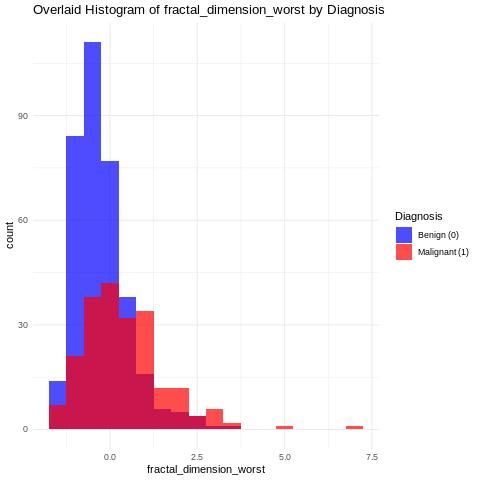

In [ ]:
%%R
library(ggplot2)

# Exclude the 'target' column from numerical columns for plotting
plot_cols <- names(data_scaled)[sapply(data_scaled, is.numeric) & names(data_scaled) != "target"]

# Print the list of columns being plotted to confirm
print(paste("Plotting histograms for these columns:", paste(plot_cols, collapse = ", ")))

# Create an empty list to store plots
plot_list <- list()

for (col in plot_cols) {
  p <- ggplot(data_scaled, aes_string(x = col, fill = "target")) +
    geom_histogram(binwidth = 0.5, alpha = 0.7, position = "identity") + # Use position = "identity" for overlay
    ggtitle(paste("Overlaid Histogram of", col, "by Diagnosis")) +
    scale_fill_manual(values = c("0" = "blue", "1" = "red"), labels = c("Benign (0)", "Malignant (1)")) + # Explicitly set colors and labels
    labs(fill = "Diagnosis") + # Legend title
    theme_minimal()

  plot_list[[col]] <- p # Store the plot in the list
}

# NOTE: Colab might truncate the display of many plots from a single cell.
# To view all plots, you can inspect the 'plot_list' object or print specific plots.
# For example, to print a specific plot:
# print(plot_list[["radius_mean"]])

# Print each plot in the list to display them (may be truncated by Colab)
for (p in plot_list) {
  print(p)
}

[1] "Plotting histograms for these columns: radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave.points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave.points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave.points_worst, symmetry_worst, fractal_dimension_worst"


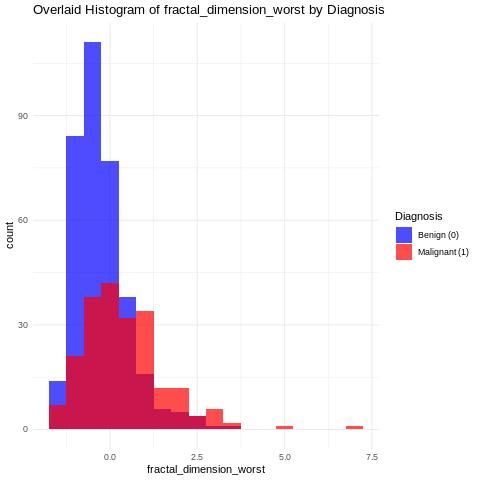

In [ ]:
%%R
library(ggplot2)

# Exclude the 'target' column from numerical columns for plotting
plot_cols <- names(data_scaled)[sapply(data_scaled, is.numeric) & names(data_scaled) != "target"]

# Print the list of columns being plotted to confirm
print(paste("Plotting histograms for these columns:", paste(plot_cols, collapse = ", ")))

# Create an empty list to store plots
plot_list <- list()

for (col in plot_cols) {
  p <- ggplot(data_scaled, aes_string(x = col, fill = "target")) +
    geom_histogram(binwidth = 0.5, alpha = 0.7, position = "identity") + # Use position = "identity" for overlay
    ggtitle(paste("Overlaid Histogram of", col, "by Diagnosis")) +
    scale_fill_manual(values = c("0" = "blue", "1" = "red"), labels = c("Benign (0)", "Malignant (1)")) + # Explicitly set colors and labels
    labs(fill = "Diagnosis") + # Legend title
    theme_minimal()

  plot_list[[col]] <- p # Store the plot in the list
}

# NOTE: Colab might truncate the display of many plots from a single cell.
# To view all plots, you can inspect the 'plot_list' object or print specific plots.
# For example, to print a specific plot:
# print(plot_list[["radius_mean"]])

# Print each plot in the list to display them (may be truncated by Colab)
for (p in plot_list) {
  print(p)
}

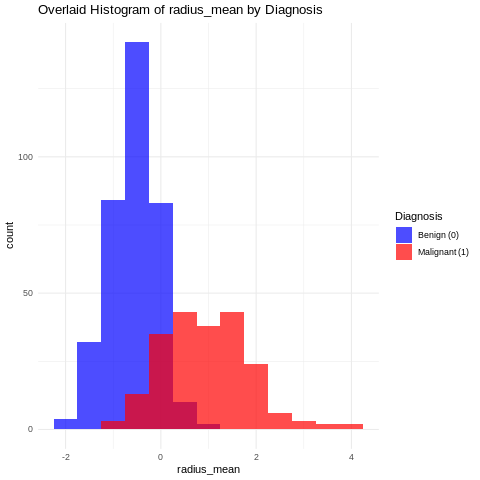

In [ ]:
%%R
print(plot_list[["radius_mean"]])

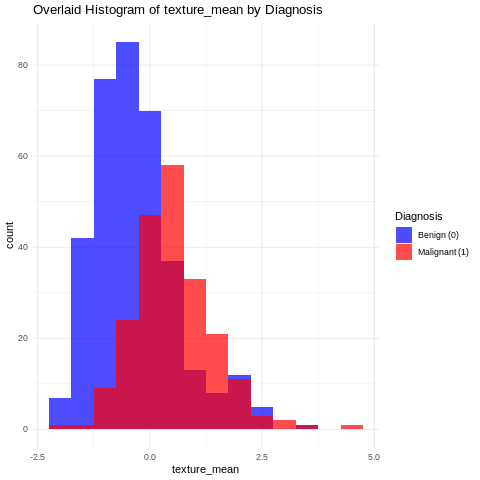

In [ ]:
%%R
print(plot_list[["texture_mean"]])

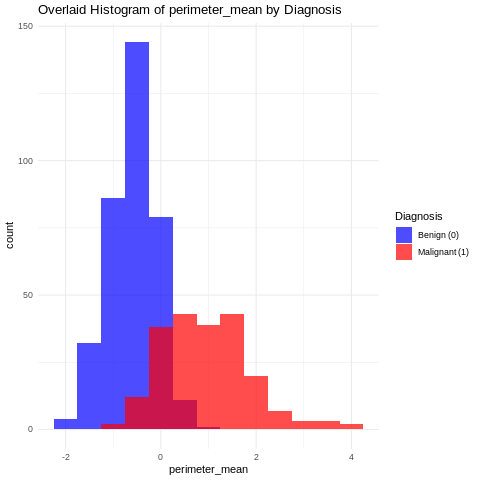

In [ ]:
%%R
print(plot_list[["perimeter_mean"]])

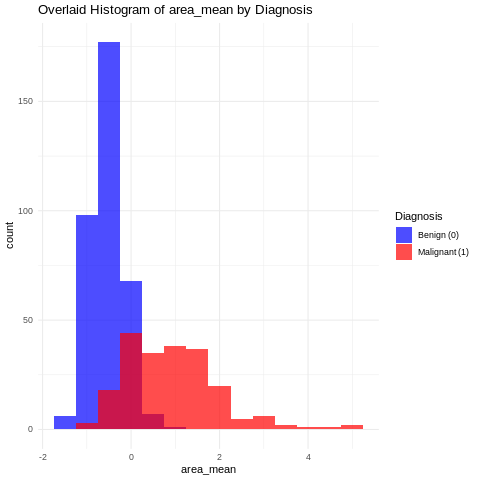

In [ ]:
%%R
print(plot_list[["area_mean"]])

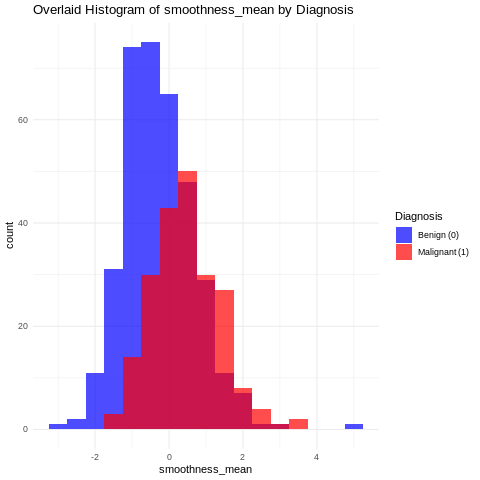

In [ ]:
%%R
print(plot_list[["smoothness_mean"]])

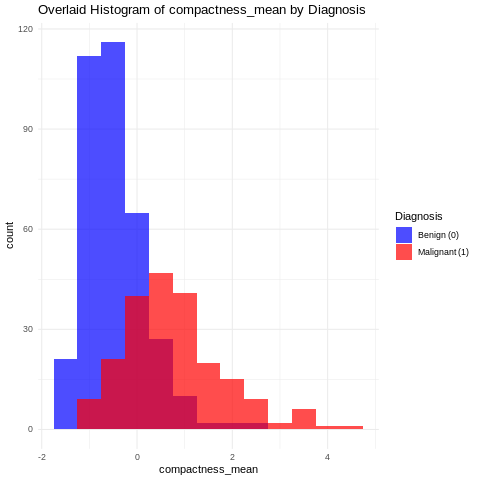

In [ ]:
%%R
print(plot_list[["compactness_mean"]])

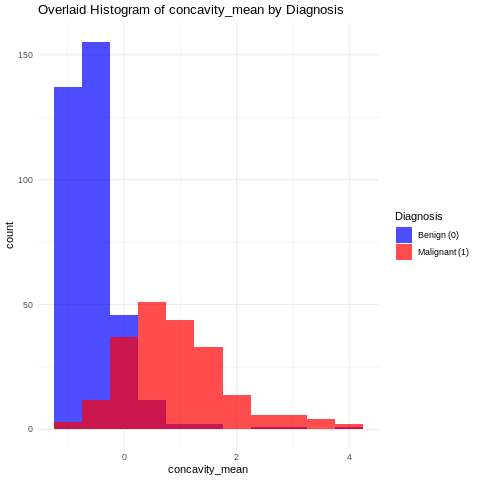

In [ ]:
%%R
print(plot_list[["concavity_mean"]])

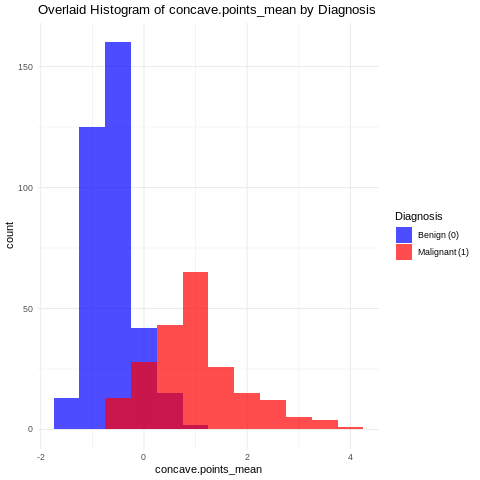

In [ ]:
%%R
print(plot_list[["concave.points_mean"]])

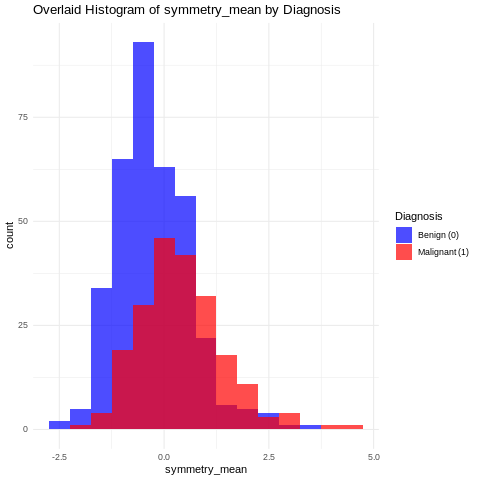

In [ ]:
%%R
print(plot_list[["symmetry_mean"]])

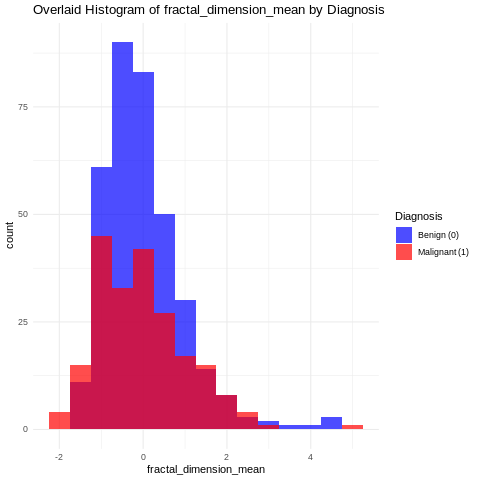

In [ ]:
%%R
print(plot_list[["fractal_dimension_mean"]])

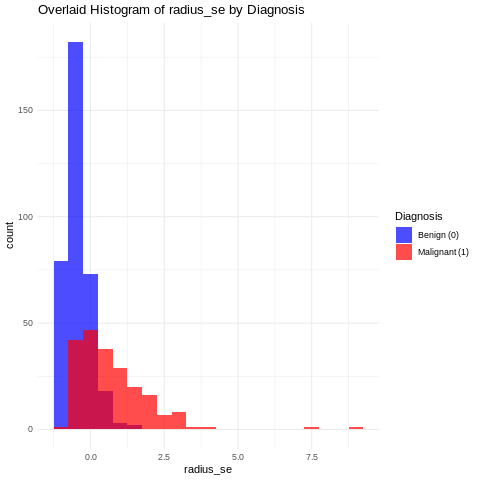

In [ ]:
%%R
print(plot_list[["radius_se"]])

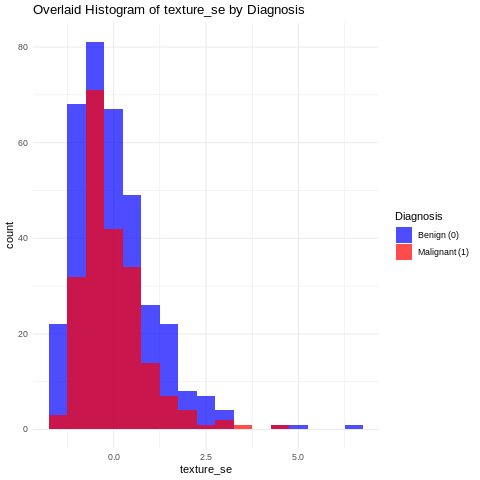

In [ ]:
%%R
print(plot_list[["texture_se"]])

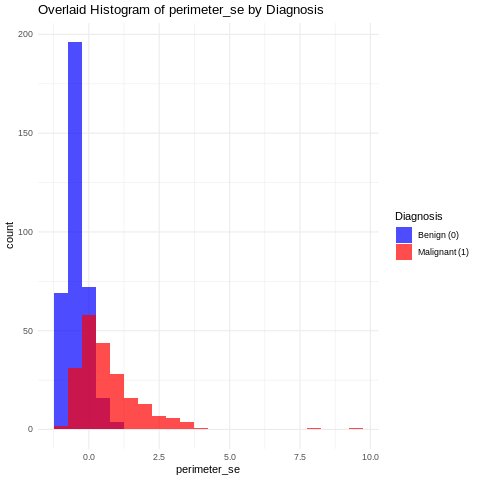

In [ ]:
%%R
print(plot_list[["perimeter_se"]])

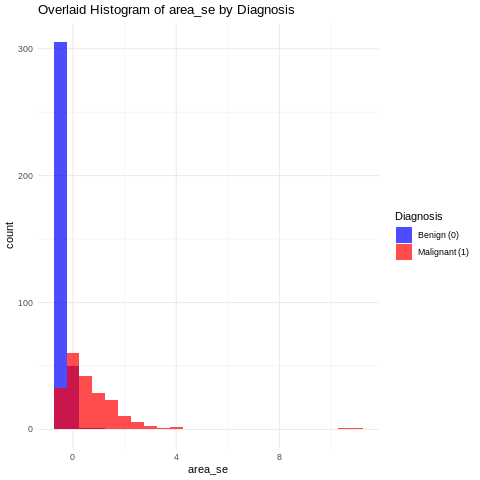

In [ ]:
%%R
print(plot_list[["area_se"]])

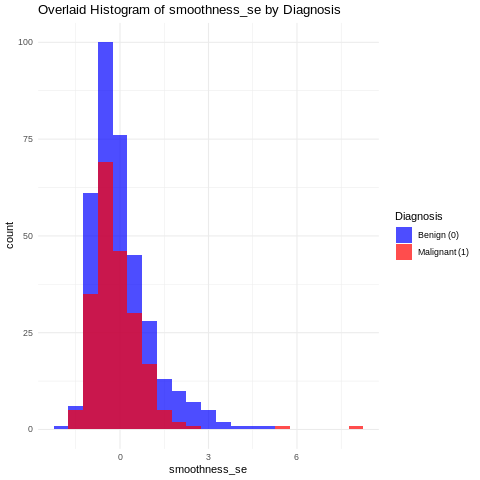

In [ ]:
%%R
print(plot_list[["smoothness_se"]])

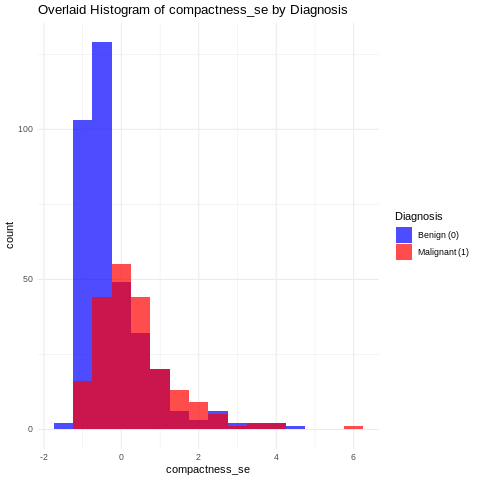

In [ ]:
%%R
print(plot_list[["compactness_se"]])

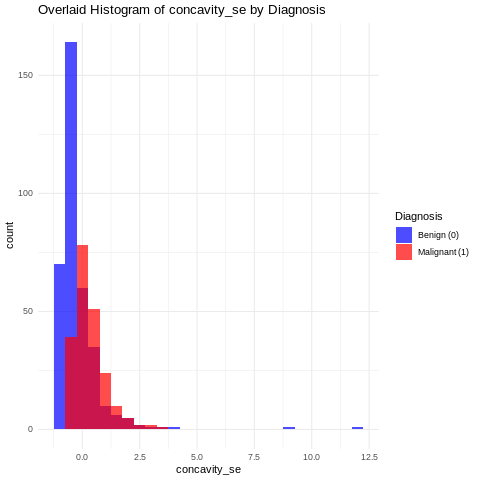

In [ ]:
%%R
print(plot_list[["concavity_se"]])

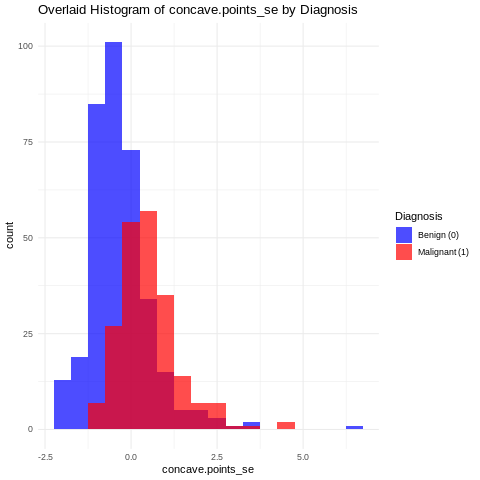

In [ ]:
%%R
print(plot_list[["concave.points_se"]])

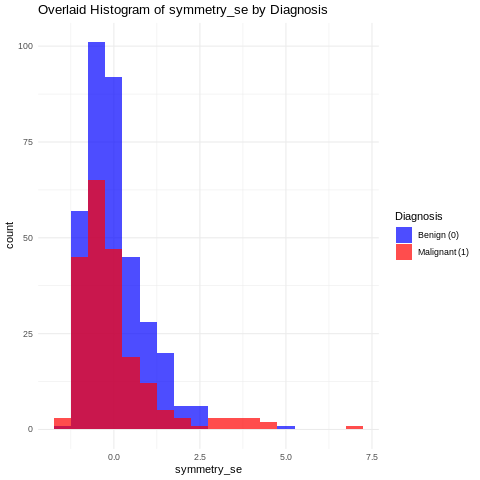

In [ ]:
%%R
print(plot_list[["symmetry_se"]])

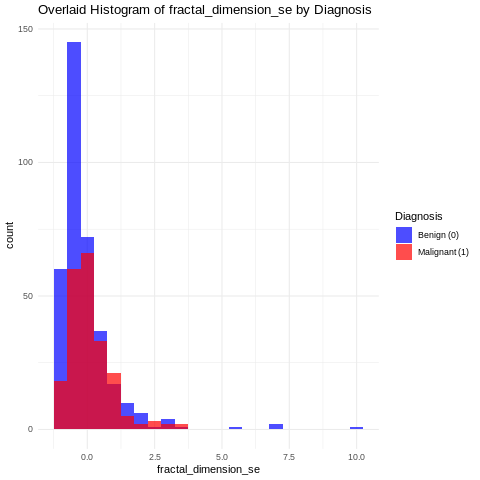

In [ ]:
%%R
print(plot_list[["fractal_dimension_se"]])

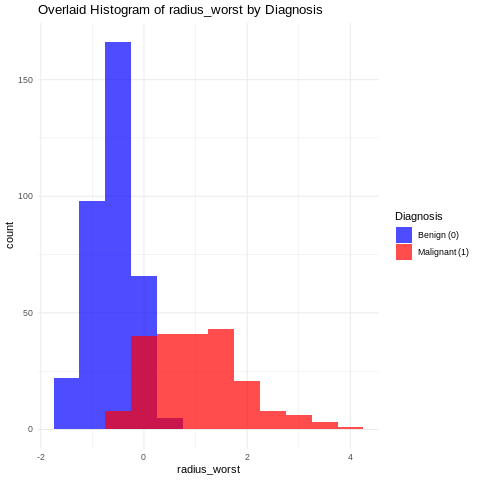

In [ ]:
%%R
print(plot_list[["radius_worst"]])

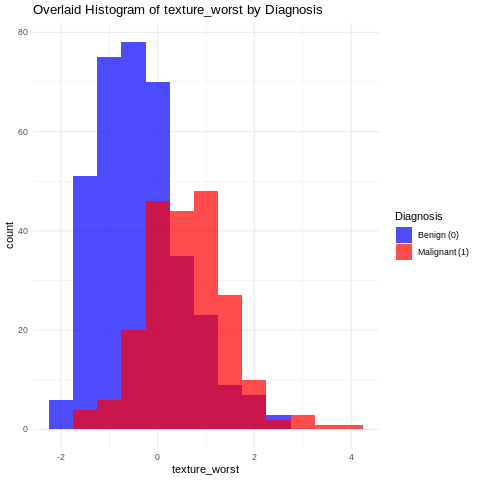

In [ ]:
%%R
print(plot_list[["texture_worst"]])

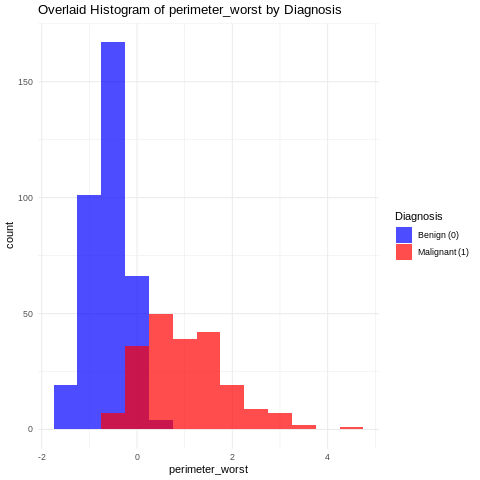

In [ ]:
%%R
print(plot_list[["perimeter_worst"]])

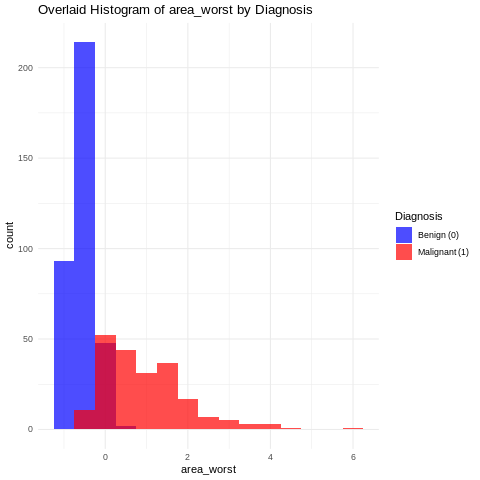

In [ ]:
%%R
print(plot_list[["area_worst"]])

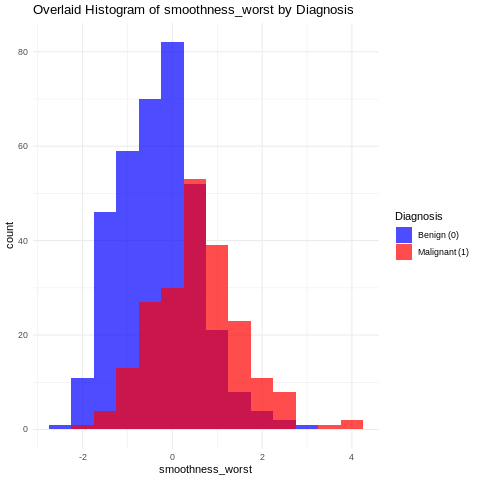

In [ ]:
%%R
print(plot_list[["smoothness_worst"]])

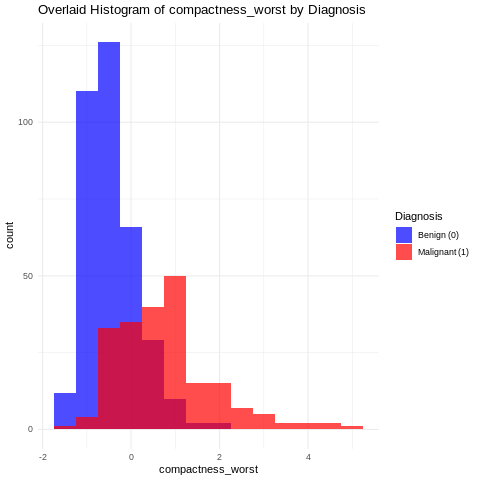

In [ ]:
%%R
print(plot_list[["compactness_worst"]])

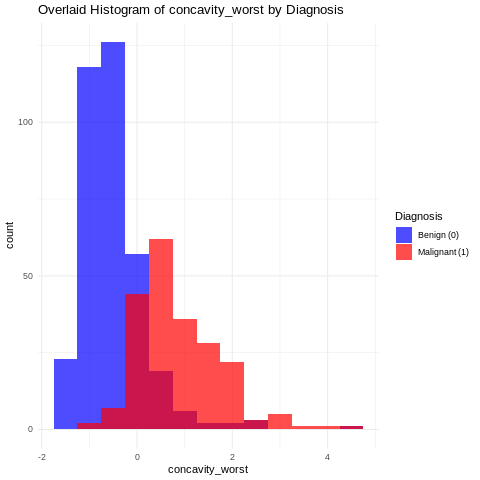

In [ ]:
%%R
print(plot_list[["concavity_worst"]])

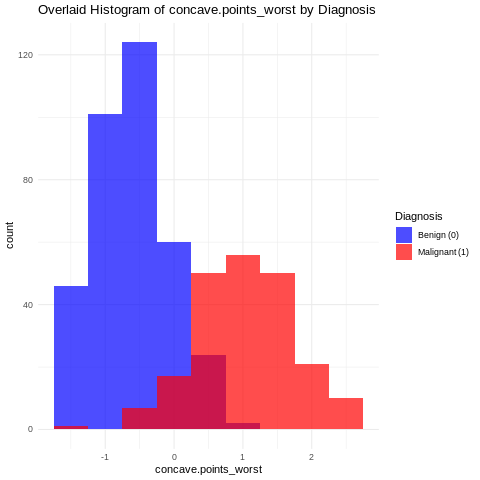

In [ ]:
%%R
print(plot_list[["concave.points_worst"]])

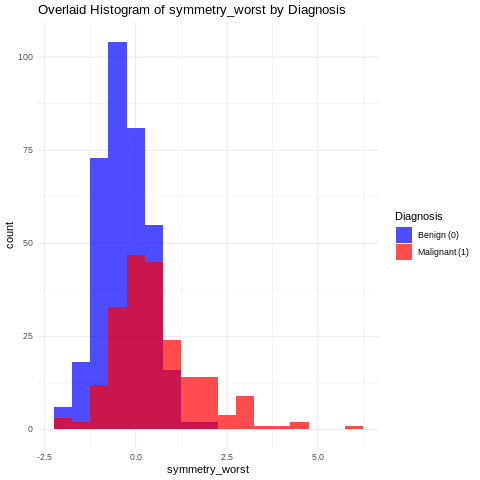

In [ ]:
%%R
print(plot_list[["symmetry_worst"]])

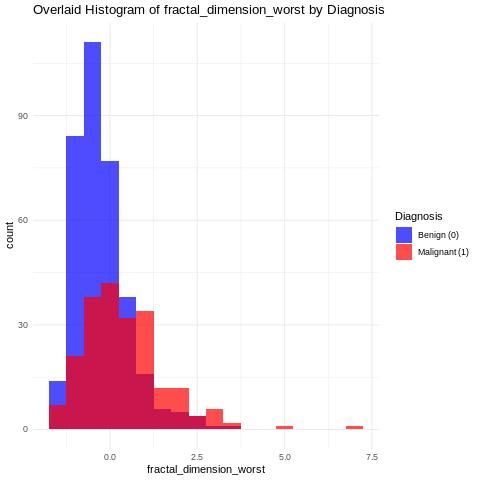

In [ ]:
%%R
print(plot_list[["fractal_dimension_worst"]])

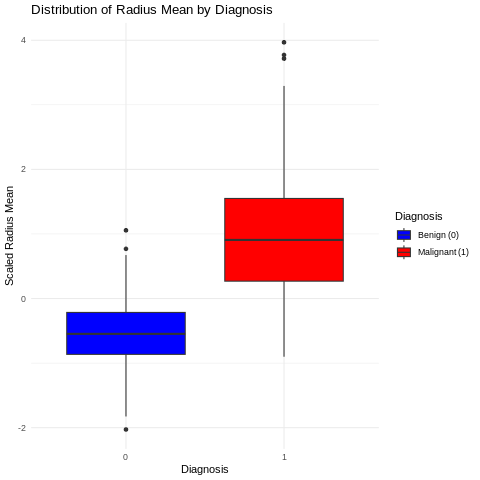

In [ ]:
%%R
library(ggplot2)

# Create a box plot for radius_mean grouped by target
p_radius_mean_boxplot <- ggplot(data_scaled, aes(x = target, y = radius_mean, fill = target)) +
  geom_boxplot() +
  scale_fill_manual(values = c("0" = "blue", "1" = "red"), labels = c("Benign (0)", "Malignant (1)")) +
  labs(title = "Distribution of Radius Mean by Diagnosis",
       x = "Diagnosis",
       y = "Scaled Radius Mean",
       fill = "Diagnosis") +
  theme_minimal()

print(p_radius_mean_boxplot)


[1] "Generating box plots for these columns: radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave.points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave.points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave.points_worst, symmetry_worst, fractal_dimension_worst"


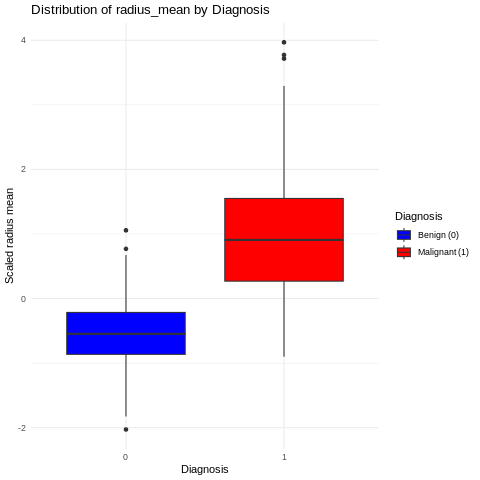

In [ ]:
%%R
library(ggplot2)

# Exclude the 'target' column from numerical columns for plotting
boxplot_cols <- names(data_scaled)[sapply(data_scaled, is.numeric) & names(data_scaled) != "target"]

# Print the list of columns for which boxplots are being generated
print(paste("Generating box plots for these columns:", paste(boxplot_cols, collapse = ", ")))

# Create an empty list to store box plots
boxplot_list <- list()

for (col in boxplot_cols) {
  p <- ggplot(data_scaled, aes_string(x = "target", y = col, fill = "target")) +
    geom_boxplot() +
    scale_fill_manual(values = c("0" = "blue", "1" = "red"), labels = c("Benign (0)", "Malignant (1)")) +
    labs(title = paste("Distribution of", col, "by Diagnosis"),
         x = "Diagnosis",
         y = paste("Scaled", gsub("_", " ", col)), # Improve y-axis label readability
         fill = "Diagnosis") +
    theme_minimal()

  boxplot_list[[col]] <- p # Store the plot in the list
}

# NOTE: Colab might truncate the display of many plots from a single cell.
# To view all plots, you can inspect the 'boxplot_list' object or print specific plots.
# For example, to print a specific plot:
# print(boxplot_list[["radius_mean"]])

# Printing all plots will likely result in truncation. It's better to print them one by one.
# For demonstrative purposes, let's print the first few:
print(boxplot_list[["radius_mean"]])


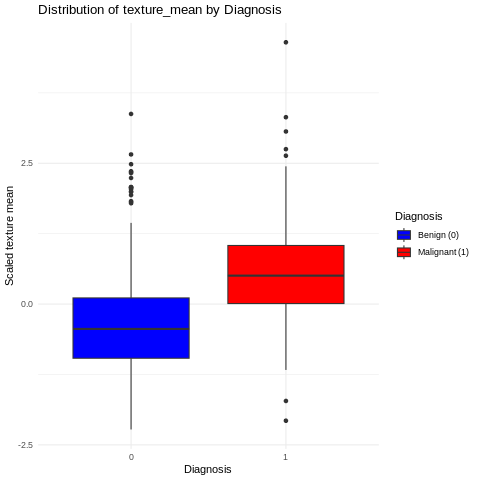

In [ ]:
%%R
print(boxplot_list[["texture_mean"]])

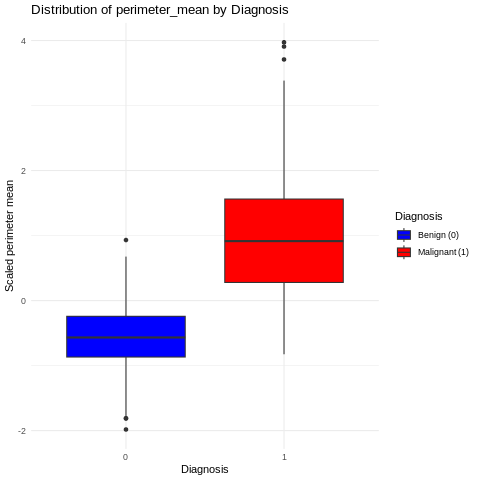

In [ ]:
%%R
print(boxplot_list[["perimeter_mean"]])

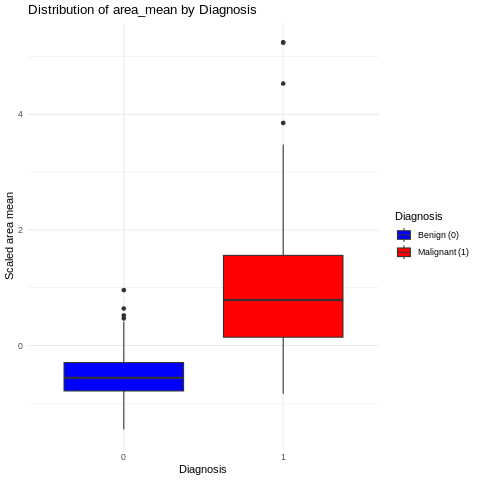

In [ ]:
%%R
print(boxplot_list[["area_mean"]])

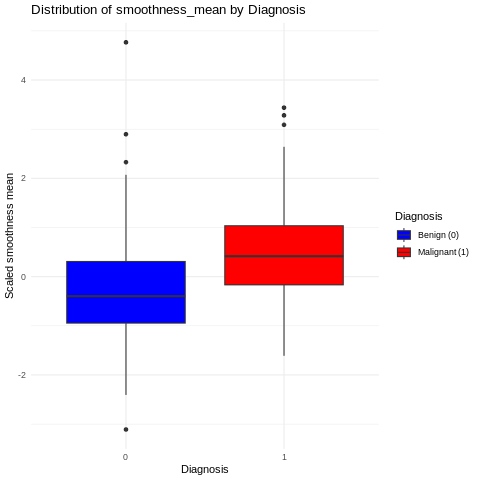

In [ ]:
%%R
print(boxplot_list[["smoothness_mean"]])

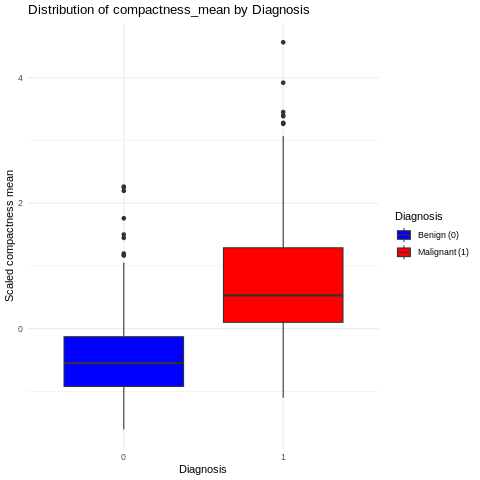

In [ ]:
%%R
print(boxplot_list[["compactness_mean"]])

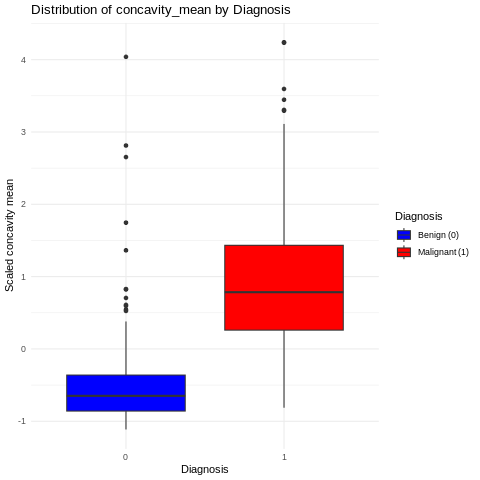

In [ ]:
%%R
print(boxplot_list[["concavity_mean"]])

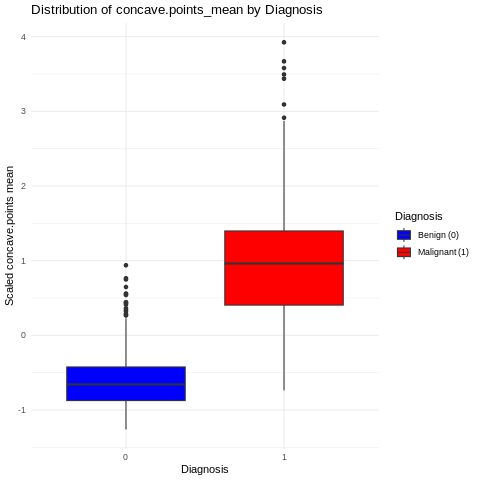

In [ ]:
%%R
print(boxplot_list[["concave.points_mean"]])

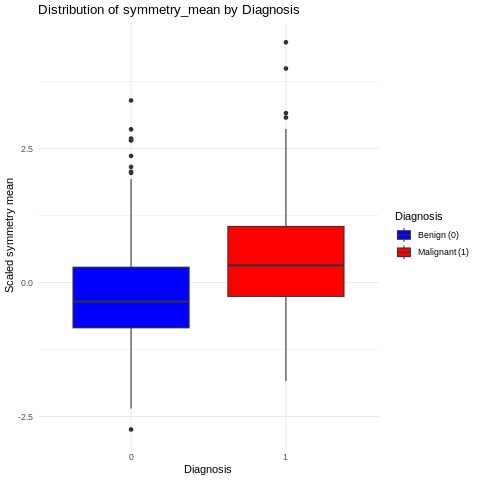

In [ ]:
%%R
print(boxplot_list[["symmetry_mean"]])

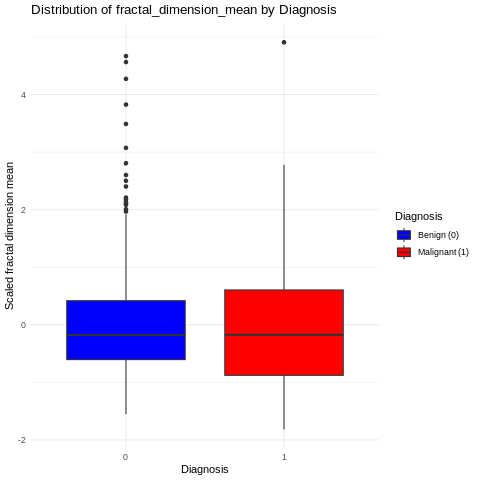

In [ ]:
%%R
print(boxplot_list[["fractal_dimension_mean"]])

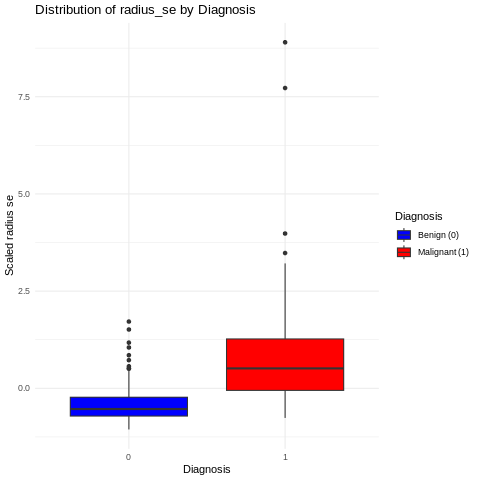

In [ ]:
%%R
print(boxplot_list[["radius_se"]])

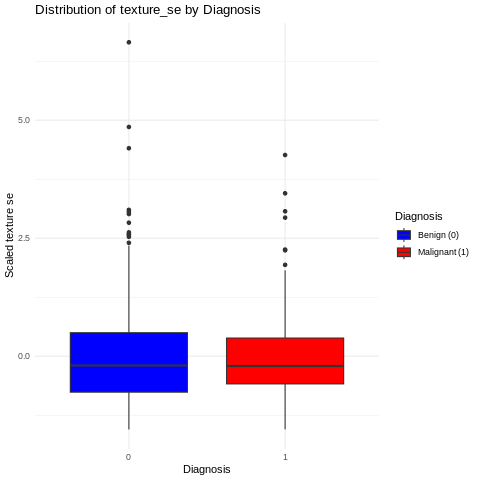

In [ ]:
%%R
print(boxplot_list[["texture_se"]])

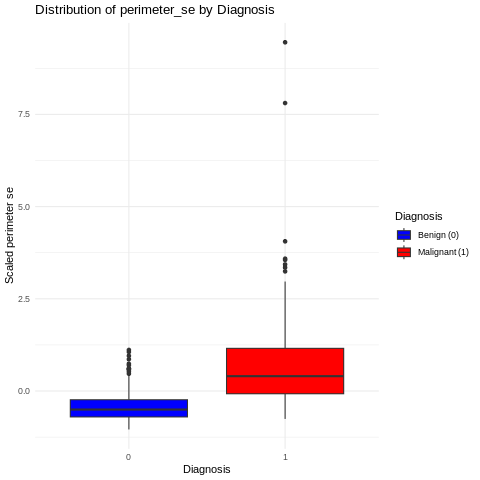

In [ ]:
%%R
print(boxplot_list[["perimeter_se"]])

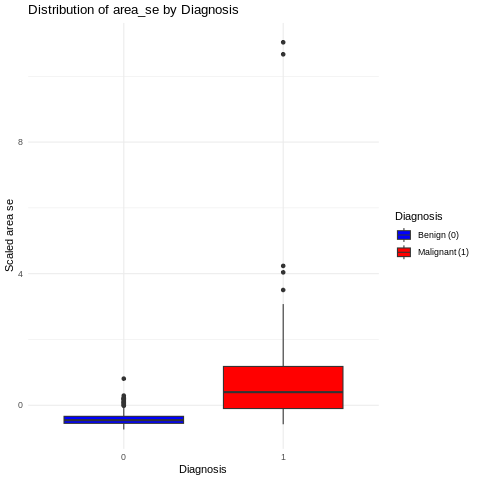

In [ ]:
%%R
print(boxplot_list[["area_se"]])

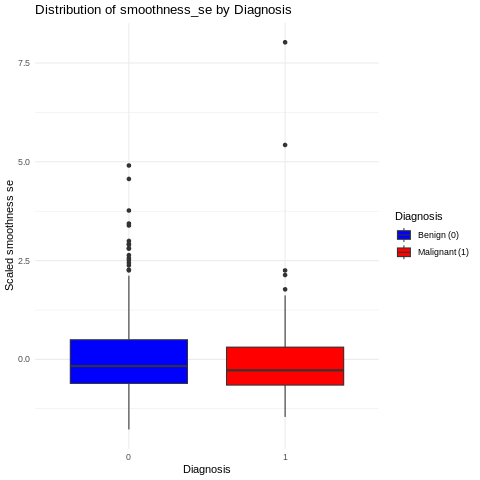

In [ ]:
%%R
print(boxplot_list[["smoothness_se"]])

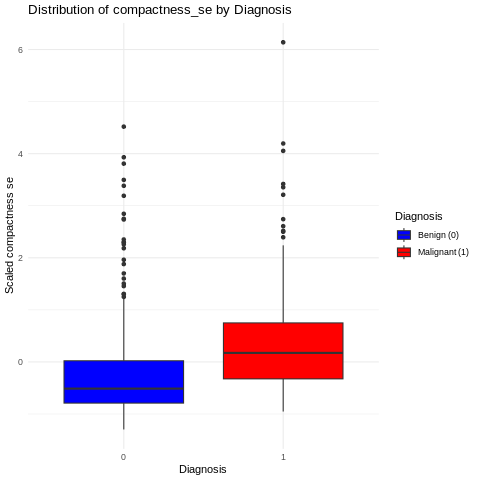

In [ ]:
%%R
print(boxplot_list[["compactness_se"]])

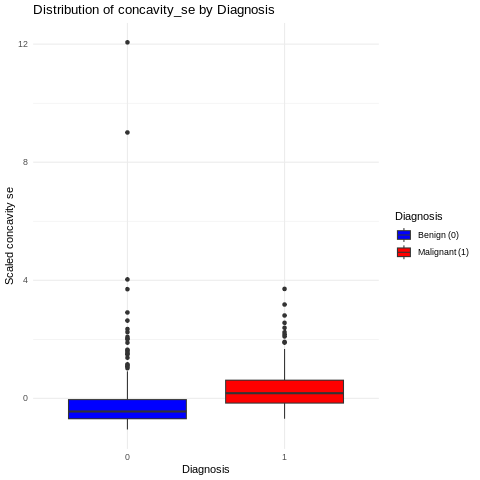

In [ ]:
%%R
print(boxplot_list[["concavity_se"]])

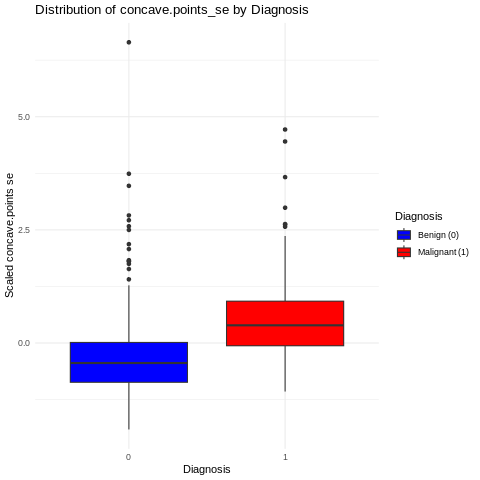

In [ ]:
%%R
print(boxplot_list[["concave.points_se"]])

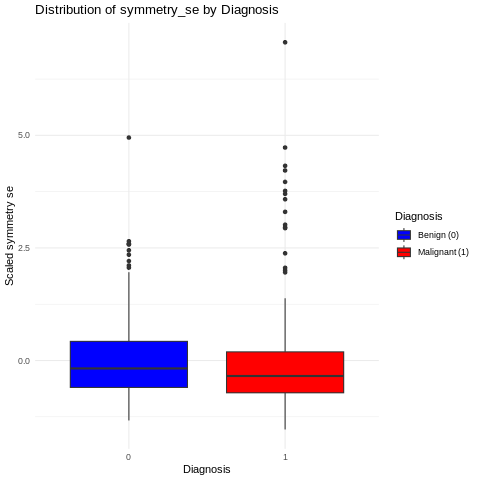

In [ ]:
%%R
print(boxplot_list[["symmetry_se"]])

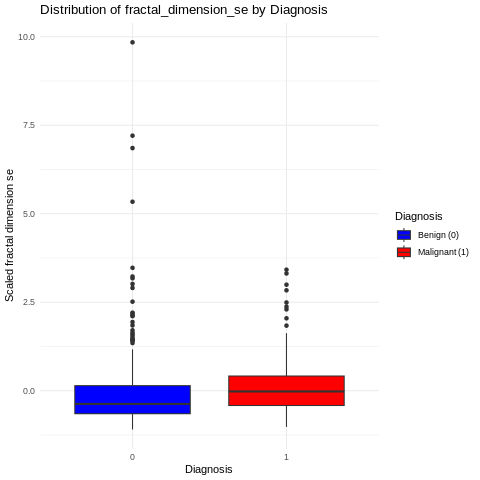

In [ ]:
%%R
print(boxplot_list[["fractal_dimension_se"]])

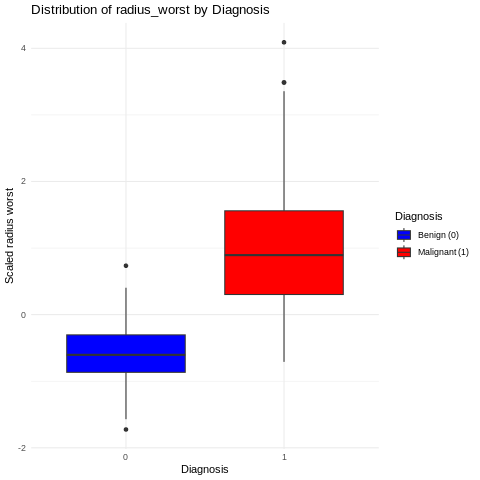

In [ ]:
%%R
print(boxplot_list[["radius_worst"]])

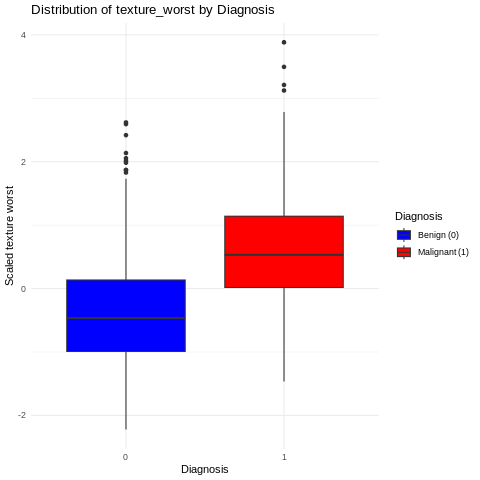

In [ ]:
%%R
print(boxplot_list[["texture_worst"]])

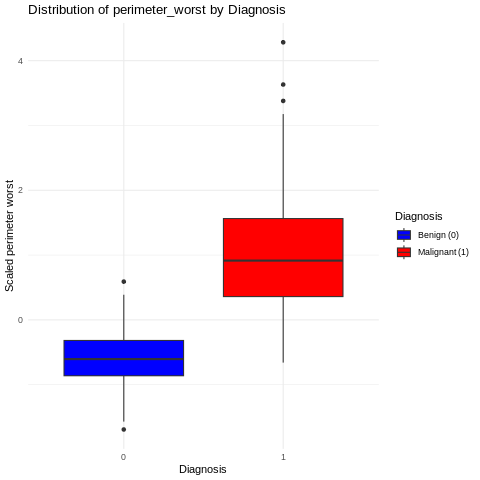

In [ ]:
%%R
print(boxplot_list[["perimeter_worst"]])

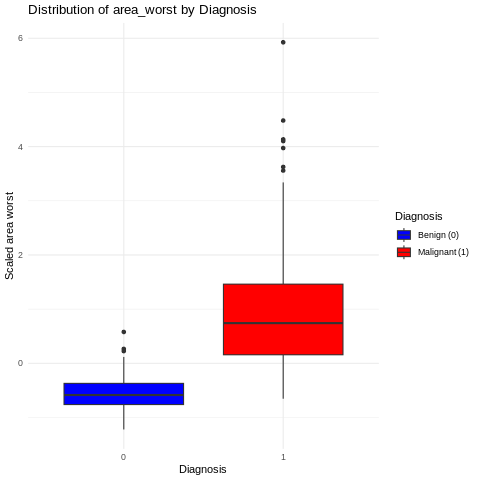

In [ ]:
%%R
print(boxplot_list[["area_worst"]])

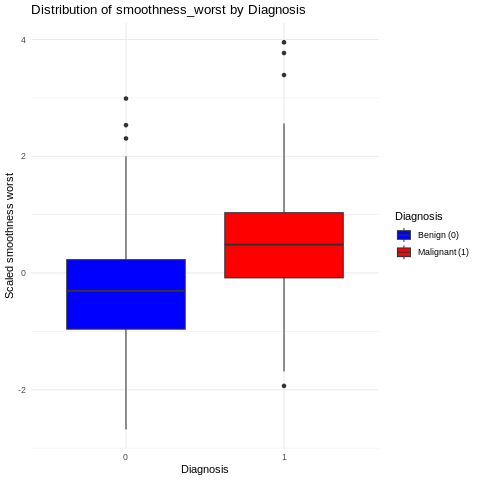

In [ ]:
%%R
print(boxplot_list[["smoothness_worst"]])

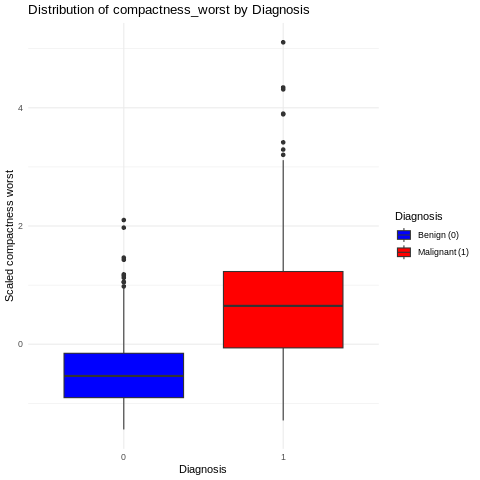

In [ ]:
%%R
print(boxplot_list[["compactness_worst"]])

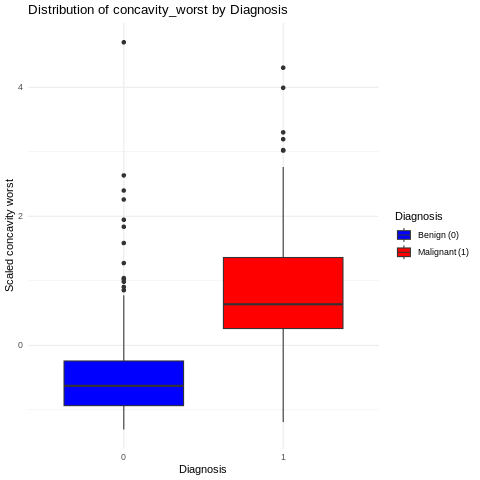

In [ ]:
%%R
print(boxplot_list[["concavity_worst"]])

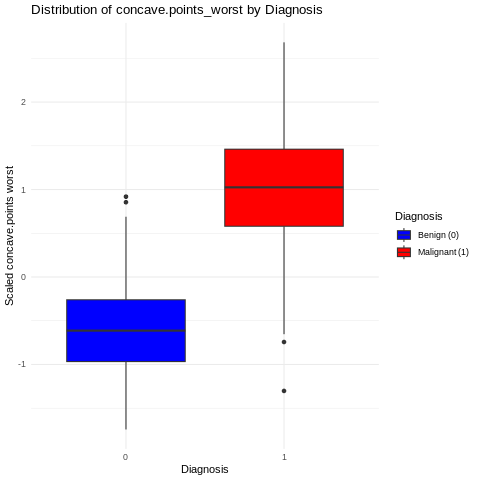

In [ ]:
%%R
print(boxplot_list[["concave.points_worst"]])

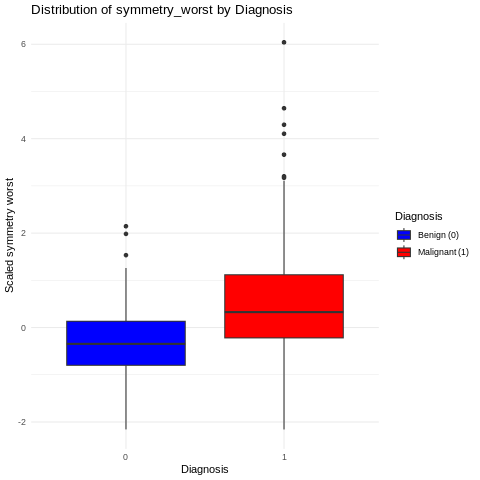

In [ ]:
%%R
print(boxplot_list[["symmetry_worst"]])

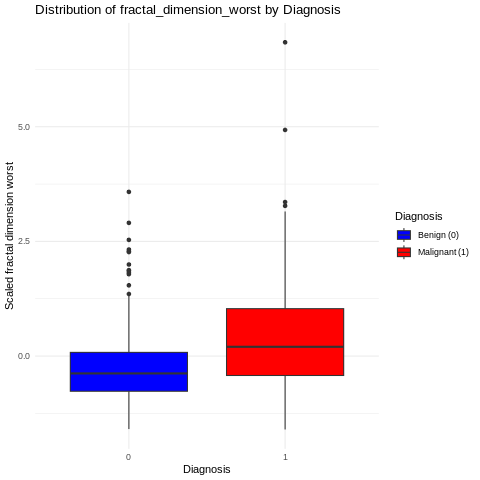

In [ ]:
%%R
print(boxplot_list[["fractal_dimension_worst"]])

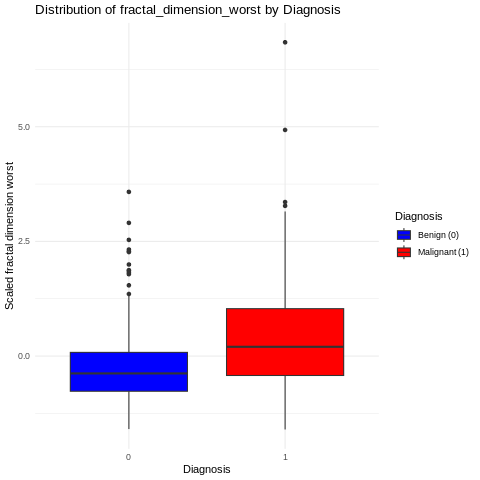

In [ ]:
%%R
print(boxplot_list[["fractal_dimension_worst"]])

In [ ]:
%%R
# Exclude the 'target' column before calculating correlation
features_for_correlation <- data_scaled[, names(data_scaled) != "target"]

# Calculate the Pearson correlation matrix
correlation_matrix <- cor(features_for_correlation, method = "pearson")

# Display the correlation matrix
print(correlation_matrix)

                         radius_mean texture_mean perimeter_mean    area_mean
radius_mean              1.000000000  0.323781891    0.997855281  0.987357170
texture_mean             0.323781891  1.000000000    0.329533059  0.321085696
perimeter_mean           0.997855281  0.329533059    1.000000000  0.986506804
area_mean                0.987357170  0.321085696    0.986506804  1.000000000
smoothness_mean          0.170581187 -0.023388516    0.207278164  0.177028377
compactness_mean         0.506123578  0.236702222    0.556936211  0.498501682
concavity_mean           0.676763550  0.302417828    0.716135650  0.685982829
concave.points_mean      0.822528522  0.293464051    0.850977041  0.823268869
symmetry_mean            0.147741242  0.071400980    0.183027212  0.151293079
fractal_dimension_mean  -0.311630826 -0.076437183   -0.261476908 -0.283109812
radius_se                0.679090388  0.275868676    0.691765014  0.732562227
texture_se              -0.097317443  0.386357623   -0.086761078

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/reshape2_1.4.5.tar.gz'
Content type 'application/x-gzip' length 38080 bytes (37 KB)
downloaded 37 KB


The downloaded source packages are in
	‘/tmp/RtmphegSjR/downloaded_packages’


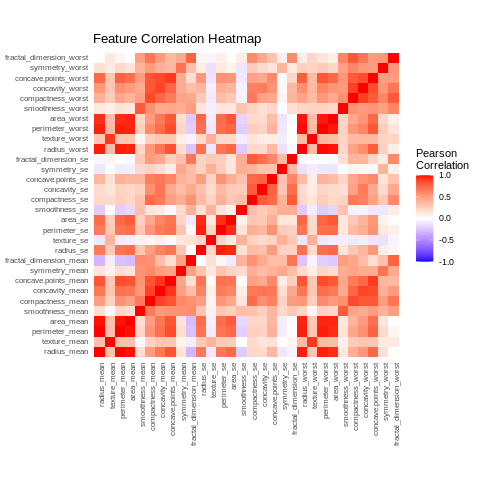

In [ ]:
%%R
install.packages('reshape2') # Install reshape2 package
library(reshape2) # For melt function
library(ggplot2) # For plotting

# Set plot dimensions to enlarge the heatmap
options(repr.plot.width = 50, repr.plot.height = 50)

# Melt the correlation matrix for ggplot2
melted_cor_matrix <- melt(correlation_matrix)

# Create the heatmap
heatmap_plot <- ggplot(melted_cor_matrix, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white",
                       midpoint = 0, limit = c(-1,1), space = "Lab",
                       name="Pearson\nCorrelation") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, vjust = 1,
                                   size = 8, hjust = 1),
        axis.text.y = element_text(size = 8),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        panel.grid.major = element_blank(),
        panel.border = element_blank(),
        panel.background = element_blank()) +
  coord_fixed() +
  labs(title = "Feature Correlation Heatmap")

print(heatmap_plot)



### Identifying Highly Correlated Features (Multicollinearity)

In [ ]:
%%R
# Set a correlation threshold to identify multicollinearity
correlation_threshold <- 0.8

# Get the feature names from the correlation matrix
feature_names <- colnames(correlation_matrix)

# Initialize a list to store highly correlated pairs
high_correlation_pairs <- list()

# Iterate through the upper triangle of the correlation matrix to avoid duplicates
for (i in 1:(ncol(correlation_matrix) - 1)) {
  for (j in (i + 1):ncol(correlation_matrix)) {
    # Check for strong positive or negative correlation
    if (abs(correlation_matrix[i, j]) > correlation_threshold) {
      high_correlation_pairs <- c(high_correlation_pairs,
                                  paste(feature_names[i], "and", feature_names[j],
                                        "(Correlation:", round(correlation_matrix[i, j], 3),")"))
    }
  }
}

# Print the identified highly correlated pairs
if (length(high_correlation_pairs) > 0) {
  cat("Features with absolute correlation greater than", correlation_threshold, ":\n")
  for (pair in high_correlation_pairs) {
    cat("- ", pair, "\n")
  }
} else {
  cat("No feature pairs found with absolute correlation greater than", correlation_threshold, ".\n")
}

Features with absolute correlation greater than 0.8 :
-  radius_mean and perimeter_mean (Correlation: 0.998 ) 
-  radius_mean and area_mean (Correlation: 0.987 ) 
-  radius_mean and concave.points_mean (Correlation: 0.823 ) 
-  radius_mean and radius_worst (Correlation: 0.97 ) 
-  radius_mean and perimeter_worst (Correlation: 0.965 ) 
-  radius_mean and area_worst (Correlation: 0.941 ) 
-  texture_mean and texture_worst (Correlation: 0.912 ) 
-  perimeter_mean and area_mean (Correlation: 0.987 ) 
-  perimeter_mean and concave.points_mean (Correlation: 0.851 ) 
-  perimeter_mean and radius_worst (Correlation: 0.969 ) 
-  perimeter_mean and perimeter_worst (Correlation: 0.97 ) 
-  perimeter_mean and area_worst (Correlation: 0.942 ) 
-  area_mean and concave.points_mean (Correlation: 0.823 ) 
-  area_mean and area_se (Correlation: 0.8 ) 
-  area_mean and radius_worst (Correlation: 0.963 ) 
-  area_mean and perimeter_worst (Correlation: 0.959 ) 
-  area_mean and area_worst (Correlation: 0.

In [ ]:
%%R
# Calculate correlation between each feature and the target variable
# Ensure the target variable is treated as numeric for correlation calculation

# Get numerical features (excluding 'target')
num_features <- data_scaled[, !(names(data_scaled) %in% c("target"))]

# Convert target to numeric (0 and 1) for correlation calculation
numeric_target <- as.numeric(as.character(data_scaled$target))

# Calculate correlation for each feature with the numeric target
correlations_with_target <- sapply(num_features, function(x) cor(x, numeric_target))

# Convert to a data frame for better display
correlations_df <- data.frame(Feature = names(correlations_with_target),
                              Correlation = correlations_with_target)

# Sort by absolute correlation value for easier interpretation
correlations_df <- correlations_df[order(abs(correlations_df$Correlation), decreasing = TRUE), ]

print("Correlations of Features with Target Variable:")
print(correlations_df)


[1] "Correlations of Features with Target Variable:"
                                        Feature  Correlation
concave.points_worst       concave.points_worst  0.793566017
perimeter_worst                 perimeter_worst  0.782914137
concave.points_mean         concave.points_mean  0.776613840
radius_worst                       radius_worst  0.776453779
perimeter_mean                   perimeter_mean  0.742635530
area_worst                           area_worst  0.733825035
radius_mean                         radius_mean  0.730028511
area_mean                             area_mean  0.708983837
concavity_mean                   concavity_mean  0.696359707
concavity_worst                 concavity_worst  0.659610210
compactness_mean               compactness_mean  0.596533678
compactness_worst             compactness_worst  0.590998238
radius_se                             radius_se  0.567133821
perimeter_se                       perimeter_se  0.556140703
area_se                         

In [ ]:
%%R
# Perform ANOVA test for each feature against the target variable using corrected_data

# Ensure 'diagnosis' in corrected_data is a factor for ANOVA
corrected_data$diagnosis <- factor(corrected_data$diagnosis)

# Get numerical features (excluding 'id', 'X', and 'diagnosis')
# 'id' and 'X' were removed earlier, 'diagnosis' is now the target factor
num_features_names <- names(corrected_data)[sapply(corrected_data, is.numeric)]

# Create an empty list to store ANOVA results
anova_results <- list()

for (feature_name in num_features_names) {
  # Create a formula for ANOVA: feature ~ diagnosis
  formula_str <- paste(feature_name, "~ diagnosis")

  # Perform ANOVA
  anova_model <- aov(as.formula(formula_str), data = corrected_data)

  # Extract p-value
  p_value <- summary(anova_model)[[1]][["Pr(>F)"]][1]

  # Store the result
  anova_results[[feature_name]] <- p_value
}

# Convert results to a data frame for better display and sorting
anova_df <- data.frame(Feature = names(anova_results),
                       P_value = unlist(anova_results))

# Sort by p-value in ascending order
anova_df <- anova_df[order(anova_df$P_value), ]

print("ANOVA Test Results (P-values sorted from most significant to least significant):")
print(anova_df)


[1] "ANOVA Test Results (P-values sorted from most significant to least significant):"
                                        Feature       P_value
concave.points_worst       concave.points_worst 1.969100e-124
perimeter_worst                 perimeter_worst 5.771397e-119
concave.points_mean         concave.points_mean 7.101150e-116
radius_worst                       radius_worst 8.482292e-116
perimeter_mean                   perimeter_mean 8.436251e-101
area_worst                           area_worst  2.828848e-97
radius_mean                         radius_mean  8.465941e-96
area_mean                             area_mean  4.734564e-88
concavity_mean                   concavity_mean  9.966556e-84
concavity_worst                 concavity_worst  2.464664e-72
compactness_mean               compactness_mean  3.938263e-56
compactness_worst             compactness_worst  7.069816e-55
radius_se                             radius_se  9.738949e-50
perimeter_se                       perimeter_

In [ ]:
%%R
install.packages('caret') # Install caret package
library(caret) # For data splitting and model training utilities
# glm is a base R function, no explicit library needed for it.


In [ ]:
%%R
# Split the dataset into predictor variables (features) and response variable (target)
x <- corrected_data[, -which(names(corrected_data) == "diagnosis")]
y <- corrected_data$diagnosis

# Display the dimensions of x and y to confirm the split
print(paste("Dimensions of features (x):", paste(dim(x), collapse = " x ")))
print(paste("Length of target (y):", length(y)))


In [ ]:
%%R
# Set k for k-fold cross-validation
k_folds <- 10

# Create stratified folds based on the target variable 'y'
set.seed(123) # for reproducibility

# createFolds automatically tries to stratify if y is a factor
# Since 'y' is already a factor (from corrected_data$diagnosis which was converted earlier),
# createFolds will handle stratification.

folds <- createFolds(y, k = k_folds, list = TRUE, returnTrain = TRUE)

# Display the structure of the folds to verify
print(paste("Number of folds created:", length(folds)))
print("First fold (training indices):")
print(head(folds[[1]]))

# Optionally, verify stratification by checking class distribution in a fold vs. original data
 original_prop <- table(y) / length(y)
 fold1_prop <- table(y[folds[[1]]]) / length(y[folds[[1]]])
 print("Original class proportions:")
 print(original_prop)
 print("First fold (training set) class proportions:")
 print(fold1_prop)

In [ ]:
%%R
# Create empty lists to store scaled data for each fold
x_scaled_train_list <- list()
x_scaled_test_list <- list()

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds[[i]]
  test_indices <- setdiff(1:nrow(x), train_indices)

  # Extract training and testing sets for features
  x_train_fold <- x[train_indices, ]
  x_test_fold <- x[test_indices, ]

  # Perform Z-score standardization on the training data
  # Calculate mean and standard deviation ONLY from the training fold
  scaler_mean <- apply(x_train_fold, 2, mean)
  scaler_sd <- apply(x_train_fold, 2, sd)

  # Apply scaling to both training and testing data using the training fold's parameters
  x_scaled_train <- scale(x_train_fold, center = scaler_mean, scale = scaler_sd)
  x_scaled_test <- scale(x_test_fold, center = scaler_mean, scale = scaler_sd)

  # Convert scaled matrices back to data frames (if necessary, for consistency with 'x')
  x_scaled_train <- as.data.frame(x_scaled_train)
  x_scaled_test <- as.data.frame(x_scaled_test)

  # Store the scaled data for the current fold
  x_scaled_train_list[[i]] <- x_scaled_train
  x_scaled_test_list[[i]] <- x_scaled_test
}

# Display dimensions for the first fold to verify
print(paste("Dimensions of scaled training features for Fold 1:", paste(dim(x_scaled_train_list[[1]]), collapse = " x ")))
print(paste("Dimensions of scaled testing features for Fold 1:", paste(dim(x_scaled_test_list[[1]]), collapse = " x ")))


In [ ]:
%%R
# Install and load pROC package for AUC calculation if not already present
if (!require(pROC)) {
  install.packages("pROC")
  library(pROC)
}

# Initialize lists to store results from each fold
predictions_list <- list() # Stores predicted class labels
predictions_probabilities_list <- list() # Stores predicted probabilities
actuals_list <- list()
models_list <- list()
accuracies <- numeric(k_folds)
sensitivities <- numeric(k_folds)
specificities <- numeric(k_folds)
precisions <- numeric(k_folds) # Added for Precision
f1_scores <- numeric(k_folds)   # Added for F1-score
aucs <- numeric(k_folds)

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds[[i]]
  test_indices <- setdiff(1:nrow(x), train_indices)

  # Prepare training and testing data for features and target
  x_train_fold <- x_scaled_train_list[[i]]
  y_train_fold <- y[train_indices]
  x_test_fold <- x_scaled_test_list[[i]]
  y_test_fold <- y[test_indices]

  # --- Handle Class Imbalance with Weights ---
  class_counts_train <- table(y_train_fold)
  total_train_samples <- sum(class_counts_train)

  # Create a weights vector for each observation in the training set
  # Weights are inversely proportional to class frequency
  weights_for_observations <- numeric(length(y_train_fold))
  for (class_label in names(class_counts_train)) {
    weights_for_observations[y_train_fold == class_label] <- total_train_samples / (2 * class_counts_train[class_label])
  }

  # Combine features and target for glm training
  # Ensure the target is named something distinct, e.g., 'target_outcome'
  train_data_glm <- as.data.frame(cbind(target_outcome = y_train_fold, x_train_fold))

  # Train Logistic Regression Model with weights
  model <- glm(target_outcome ~ ., data = train_data_glm, family = binomial(link = "logit"), weights = weights_for_observations)
  models_list[[i]] <- model

  # Make predictions on the scaled test set
  predictions_prob <- predict(model, newdata = x_test_fold, type = "response")

  # Convert probabilities to class labels (0 or 1) using a threshold of 0.5
  # Ensure levels are consistent with y_test_fold
  predictions_class <- factor(ifelse(predictions_prob > 0.5, "1", "0"), levels = levels(y_test_fold))

  # Store predictions and actuals
  predictions_list[[i]] <- predictions_class
  predictions_probabilities_list[[i]] <- predictions_prob # Store probabilities
  actuals_list[[i]] <- y_test_fold

  # --- Evaluate the model for this fold ---
  # Use caret's confusionMatrix for comprehensive metrics
  # Ensure that 'y_test_fold' (reference) and 'predictions_class' (data) have the same levels
  # and that 'positive' argument correctly specifies the positive class.
  cm <- confusionMatrix(predictions_class, y_test_fold, positive = "1")
  accuracies[i] <- cm$overall['Accuracy']
  sensitivities[i] <- cm$byClass['Sensitivity']
  specificities[i] <- cm$byClass['Specificity']
  precisions[i] <- cm$byClass['Precision'] # Store Precision
  f1_scores[i] <- cm$byClass['F1']         # Store F1-score

  # Calculate AUC for this fold
  roc_obj <- roc(response = y_test_fold, predictor = predictions_prob)
  aucs[i] <- auc(roc_obj)
}

# --- Aggregate Results ---
# Calculate average metrics across all folds
mean_accuracy <- mean(accuracies)
mean_sensitivity <- mean(sensitivities, na.rm = TRUE)
mean_specificity <- mean(specificities, na.rm = TRUE)
mean_precision <- mean(precisions, na.rm = TRUE) # Calculate mean Precision
mean_f1_score <- mean(f1_scores, na.rm = TRUE)     # Calculate mean F1-score
mean_auc <- mean(aucs, na.rm = TRUE)


# Print aggregated results
print(paste("Average Accuracy across folds:", round(mean_accuracy, 4)))
print(paste("Average Sensitivity (Recall) across folds:", round(mean_sensitivity, 4)))
print(paste("Average Specificity across folds:", round(mean_specificity, 4)))
print(paste("Average Precision across folds:", round(mean_precision, 4)))
print(paste("Average F1-score across folds:", round(mean_f1_score, 4)))
print(paste("Average AUC across folds:", round(mean_auc, 4)))

In [ ]:
%%R
# Store the average performance metrics as a baseline for comparison
baseline_model_results <- list(
  accuracy = mean_accuracy,
  sensitivity = mean_sensitivity,
  specificity = mean_specificity,
  precision = mean_precision,
  f1_score = mean_f1_score,
  auc = mean_auc
)

print("Baseline Model Results:")
print(baseline_model_results)

### AIC and BIC for Model Comparison

In [ ]:
%%R
# Calculate AIC and BIC for the baseline model (all features)
install.packages('AICcmodavg') # Install package if not already present
library(AICcmodavg)

aic_baseline_models <- sapply(models_list, AIC)
bic_baseline_models <- sapply(models_list, BIC)

mean_aic_baseline <- mean(aic_baseline_models)
mean_bic_baseline <- mean(bic_baseline_models)

print(paste("Average AIC for Baseline Model:", round(mean_aic_baseline, 4)))
print(paste("Average BIC for Baseline Model:", round(mean_bic_baseline, 4)))

In [ ]:
%%R
# Calculate AIC and BIC for the LASSO feature-selected model

aic_lasso_models <- sapply(models_list_lasso, AIC)
bic_lasso_models <- sapply(models_list_lasso, BIC)

mean_aic_lasso <- mean(aic_lasso_models)
mean_bic_lasso <- mean(bic_lasso_models)

print(paste("Average AIC for LASSO Feature-Selected Model:", round(mean_aic_lasso, 4)))
print(paste("Average BIC for LASSO Feature-Selected Model:", round(mean_bic_lasso, 4)))

### Comparison of Models based on Performance Metrics, AIC, and BIC

Let's put all the evaluation metrics and model selection criteria together for a comprehensive comparison.

In [ ]:
%%R
# Create a comparison dataframe
comparison_df <- data.frame(
  Metric = c("Accuracy", "Sensitivity", "Specificity", "Precision", "F1-score", "AUC", "AIC", "BIC"),
  Baseline_Model = c(
    baseline_model_results$accuracy,
    baseline_model_results$sensitivity,
    baseline_model_results$specificity,
    baseline_model_results$precision,
    baseline_model_results$f1_score,
    baseline_model_results$auc,
    mean_aic_baseline,
    mean_bic_baseline
  ),
  Lasso_Model = c(
    mean_accuracy_lasso,
    mean_sensitivity_lasso,
    mean_specificity_lasso,
    mean_precision_lasso,
    mean_f1_score_lasso,
    mean_auc_lasso,
    mean_aic_lasso,
    mean_bic_lasso
  ),
  Selected_Feature_Model = c(
    mean_accuracy_selected,
    mean_sensitivity_selected,
    mean_specificity_selected,
    mean_precision_selected,
    mean_f1_score_selected,
    mean_auc_selected,
    # For AIC/BIC of the selected feature model, we need to calculate it similarly to the other models.
    # Assuming models_list_selected contains the glm models for the selected features
    mean(sapply(models_list_selected, AIC)),
    mean(sapply(models_list_selected, BIC))
  )
)

# Apply rounding to only the numeric columns
comparison_df$Baseline_Model <- round(comparison_df$Baseline_Model, 4)
comparison_df$Lasso_Model <- round(comparison_df$Lasso_Model, 4)
comparison_df$Selected_Feature_Model <- round(comparison_df$Selected_Feature_Model, 4)

print("Model Comparison:")
print(comparison_df)

In [ ]:
%%R
# Define the list of selected features
selected_features <- c(

"concave.points_worst",
  "perimeter_worst",
  "compactness_mean",
  "radius_mean",
  "texture_worst",
  "smoothness_worst",
  "symmetry_worst",
  "concave.points_se"


)

# Create the new dataset by selecting the specified features and the target variable
# Ensure 'diagnosis' is included as the target variable
feature_selected_data <- corrected_data[, c(selected_features, "diagnosis")]

# Display the first few rows of the new dataset to verify
print("Head of the feature-selected dataset:")
head(feature_selected_data)

# Display the dimensions of the new dataset
print("Dimensions of the feature-selected dataset:")
dim(feature_selected_data)

### Checking Multicollinearity Among Selected Features and ANOVA Significance

In [ ]:
%%R
# Extract the correlation matrix for only the selected features
selected_correlation_matrix <- correlation_matrix[selected_features, selected_features]

# Print the correlation matrix for selected features
print("Correlation matrix for selected features:")
print(selected_correlation_matrix)

# Set a correlation threshold to identify multicollinearity
correlation_threshold <- 0.8

# Initialize a list to store highly correlated pairs among selected features
high_correlation_pairs_selected <- list()

# Iterate through the upper triangle of the selected correlation matrix
for (i in 1:(ncol(selected_correlation_matrix) - 1)) {
  for (j in (i + 1):ncol(selected_correlation_matrix)) {
    if (abs(selected_correlation_matrix[i, j]) > correlation_threshold) {
      high_correlation_pairs_selected <- c(high_correlation_pairs_selected,
                                          paste(colnames(selected_correlation_matrix)[i], "and", colnames(selected_correlation_matrix)[j],
                                                "(Correlation:", round(selected_correlation_matrix[i, j], 3),")"))
    }
  }
}

# Print the identified highly correlated pairs among selected features
if (length(high_correlation_pairs_selected) > 0) {
  cat("Highly correlated pairs among selected features (absolute correlation >", correlation_threshold, "):")
  for (pair in high_correlation_pairs_selected) {
    cat("- ", pair, "\n")
  }
} else {
  cat("No highly correlated pairs found among selected features (absolute correlation >", correlation_threshold, ").\n")
}

# Extract ANOVA p-values for the selected features
anova_selected_features <- anova_df[anova_df$Feature %in% selected_features, ]

print("\nANOVA P-values for selected features (sorted by significance):")
print(anova_selected_features[order(anova_selected_features$P_value), ])

### Training and Evaluating Logistic Regression with Selected Features

In [ ]:
%%R
# Split the feature-selected dataset into predictor variables (features) and response variable (target)
x_selected <- feature_selected_data[, -which(names(feature_selected_data) == "diagnosis")]
y_selected <- feature_selected_data$diagnosis

# Display the dimensions of x_selected and y_selected to confirm the split
print(paste("Dimensions of selected features (x_selected):", paste(dim(x_selected), collapse = " x ")))
print(paste("Length of selected target (y_selected):", length(y_selected)))

In [ ]:
%%R
# Create stratified folds based on the target variable 'y_selected'
set.seed(123) # for reproducibility
k_folds <- 10 # Explicitly set k_folds for this block

folds_selected <- createFolds(y_selected, k = k_folds, list = TRUE, returnTrain = TRUE)

# Display the structure of the folds to verify
print(paste("Number of folds created for selected features:", length(folds_selected)))
print("First fold (training indices) for selected features:")
print(head(folds_selected[[1]]))

In [ ]:
%%R
# Create empty lists to store scaled data for each fold for selected features
x_selected_scaled_train_list <- list()
x_selected_scaled_test_list <- list()

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds_selected[[i]]
  test_indices <- setdiff(1:nrow(x_selected), train_indices)

  # Extract training and testing sets for selected features
  x_selected_train_fold <- x_selected[train_indices, ]
  x_selected_test_fold <- x_selected[test_indices, ]

  # Perform Z-score standardization on the training data
  # Calculate mean and standard deviation ONLY from the training fold
  scaler_mean_selected <- apply(x_selected_train_fold, 2, mean)
  scaler_sd_selected <- apply(x_selected_train_fold, 2, sd)

  # Apply scaling to both training and testing data using the training fold's parameters
  x_selected_scaled_train <- scale(x_selected_train_fold, center = scaler_mean_selected, scale = scaler_sd_selected)
  x_selected_scaled_test <- scale(x_selected_test_fold, center = scaler_mean_selected, scale = scaler_sd_selected)

  # Convert scaled matrices back to data frames
  x_selected_scaled_train <- as.data.frame(x_selected_scaled_train)
  x_selected_scaled_test <- as.data.frame(x_selected_scaled_test)

  # Store the scaled data for the current fold
  x_selected_scaled_train_list[[i]] <- x_selected_scaled_train
  x_selected_scaled_test_list[[i]] <- x_selected_scaled_test
}

# Display dimensions for the first fold to verify
print(paste("Dimensions of scaled training features (selected) for Fold 1:", paste(dim(x_selected_scaled_train_list[[1]]), collapse = " x ")))
print(paste("Dimensions of scaled testing features (selected) for Fold 1:", paste(dim(x_selected_scaled_test_list[[1]]), collapse = " x ")))

In [ ]:
%%R
# Initialize lists to store results from each fold for the feature-selected model
predictions_list_selected <- list() # Stores predicted class labels
predictions_probabilities_list_selected <- list() # Stores predicted probabilities
actuals_list_selected <- list()
models_list_selected <- list()
accuracies_selected <- numeric(k_folds)
sensitivities_selected <- numeric(k_folds)
specificities_selected <- numeric(k_folds)
precisions_selected <- numeric(k_folds)
f1_scores_selected <- numeric(k_folds)
aucs_selected <- numeric(k_folds)

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds_selected[[i]]
  test_indices <- setdiff(1:nrow(x_selected), train_indices)

  # Prepare training and testing data for selected features and target
  x_train_fold_selected <- x_selected_scaled_train_list[[i]]
  y_train_fold_selected <- y_selected[train_indices]
  x_test_fold_selected <- x_selected_scaled_test_list[[i]]
  y_test_fold_selected <- y_selected[test_indices]

  # --- Handle Class Imbalance with Weights --- for selected features
  class_counts_train_selected <- table(y_train_fold_selected)
  total_train_samples_selected <- sum(class_counts_train_selected)

  weights_for_observations_selected <- numeric(length(y_train_fold_selected))
  for (class_label in names(class_counts_train_selected)) {
    weights_for_observations_selected[y_train_fold_selected == class_label] <- total_train_samples_selected / (2 * class_counts_train_selected[class_label])
  }

  # Combine features and target for glm training for selected features
  train_data_glm_selected <- as.data.frame(cbind(target_outcome = y_train_fold_selected, x_train_fold_selected))

  # Train Logistic Regression Model with weights for selected features
  model_selected <- glm(target_outcome ~ ., data = train_data_glm_selected, family = binomial(link = "logit"), weights = weights_for_observations_selected)
  models_list_selected[[i]] <- model_selected

  # Make predictions on the scaled test set for selected features
  predictions_prob_selected <- predict(model_selected, newdata = x_test_fold_selected, type = "response")

  # Convert probabilities to class labels (0 or 1) using a threshold of 0.5
  predictions_class_selected <- factor(ifelse(predictions_prob_selected > 0.5, "1", "0"), levels = levels(y_test_fold_selected))

  # Store predictions and actuals for selected features
  predictions_list_selected[[i]] <- predictions_class_selected
  predictions_probabilities_list_selected[[i]] <- predictions_prob_selected
  actuals_list_selected[[i]] <- y_test_fold_selected

  # --- Evaluate the model for this fold --- for selected features
  cm_selected <- confusionMatrix(predictions_class_selected, y_test_fold_selected, positive = "1")
  accuracies_selected[i] <- cm_selected$overall['Accuracy']
  sensitivities_selected[i] <- cm_selected$byClass['Sensitivity']
  specificities_selected[i] <- cm_selected$byClass['Specificity']
  precisions_selected[i] <- cm_selected$byClass['Precision']
  f1_scores_selected[i] <- cm_selected$byClass['F1']

  # Calculate AUC for this fold for selected features
  roc_obj_selected <- roc(response = y_test_fold_selected, predictor = predictions_prob_selected)
  aucs_selected[i] <- auc(roc_obj_selected)
}

# --- Aggregate Results --- for selected features
mean_accuracy_selected <- mean(accuracies_selected)
mean_sensitivity_selected <- mean(sensitivities_selected, na.rm = TRUE)
mean_specificity_selected <- mean(specificities_selected, na.rm = TRUE)
mean_precision_selected <- mean(precisions_selected, na.rm = TRUE)
mean_f1_score_selected <- mean(f1_scores_selected, na.rm = TRUE)
mean_auc_selected <- mean(aucs_selected, na.rm = TRUE)

# Print aggregated results for selected features
print(paste("Average Accuracy (Selected Features) across folds:", round(mean_accuracy_selected, 4)))
print(paste("Average Sensitivity (Recall) (Selected Features) across folds:", round(mean_sensitivity_selected, 4)))
print(paste("Average Specificity (Selected Features) across folds:", round(mean_specificity_selected, 4)))
print(paste("Average Precision (Selected Features) across folds:", round(mean_precision_selected, 4)))
print(paste("Average F1-score (Selected Features) across folds:", round(mean_f1_score_selected, 4)))
print(paste("Average AUC (Selected Features) across folds:", round(mean_auc_selected, 4)))

In [ ]:
%%R
# Perform a paired t-test on the accuracy scores
t_test_result <- t.test(accuracies, accuracies_selected, paired = TRUE)

# Print the t-test result
print("Paired t-test results for Baseline vs. Selected Feature Model accuracies:")
print(t_test_result)

# Interpret the results based on the p-value
if (t_test_result$p.value < 0.05) {
  cat("\nThe p-value (", round(t_test_result$p.value, 4), ") is less than 0.05, indicating a statistically significant difference in accuracy between the two models.\n")
  if (mean(accuracies_selected) > mean(accuracies)) {
    cat("The selected feature model shows a statistically significant improvement in accuracy compared to the baseline model.\n")
  } else {
    cat("The baseline model shows a statistically significant improvement in accuracy compared to the selected feature model.\n")
  }
} else {
  cat("\nThe p-value (", round(t_test_result$p.value, 4), ") is not less than 0.05, indicating no statistically significant difference in accuracy between the two models.\n")
}

### LASSO Logistic Regression for Feature Selection

We will use LASSO (Least Absolute Shrinkage and Selection Operator) logistic regression to perform feature selection. LASSO introduces a penalty that shrinks some coefficient estimates to exactly zero, effectively performing feature selection. We'll use cross-validation to find the optimal regularization parameter (`lambda`).

In [ ]:
%%R
install.packages('glmnet') # Install glmnet package for LASSO regression
library(glmnet) # Load the glmnet package

# Load the corrected_data (already available from previous steps)
# Separate features (X) and target variable (y)
X <- corrected_data[, -which(names(corrected_data) == "diagnosis")]
y <- corrected_data$diagnosis

# Ensure the target variable is properly encoded as a factor for classification
# (It should already be a factor from previous steps, but re-confirming)
y <- factor(y, levels = c("0", "1"))

# Display dimensions to confirm
print(paste("Dimensions of features (X):", paste(dim(X), collapse = " x ")))
print(paste("Length of target (y):", length(y)))

#### Data Splitting and Standardization

In [ ]:
%%R
# Split the dataset into training and testing sets (80% training, 20% testing)
set.seed(123) # for reproducibility

train_indices <- createDataPartition(y, p = 0.8, list = FALSE)

X_train <- X[train_indices, ]
y_train <- y[train_indices]

X_test <- X[-train_indices, ]
y_test <- y[-train_indices]

print(paste("Dimensions of X_train:", paste(dim(X_train), collapse = " x ")))
print(paste("Length of y_train:", length(y_train)))
print(paste("Dimensions of X_test:", paste(dim(X_test), collapse = " x ")))
print(paste("Length of y_test:", length(y_test)))

# Apply Z-score standardization to the feature variables
# Using only the training data statistics (mean and standard deviation)
scaler_mean_lasso <- apply(X_train, 2, mean)
scaler_sd_lasso <- apply(X_train, 2, sd)

X_train_scaled <- scale(X_train, center = scaler_mean_lasso, scale = scaler_sd_lasso)
X_test_scaled <- scale(X_test, center = scaler_mean_lasso, scale = scaler_sd_lasso)

# Convert to data frames for consistency
X_train_scaled <- as.data.frame(X_train_scaled)
X_test_scaled <- as.data.frame(X_test_scaled)

print("Head of scaled training features:")
print(head(X_train_scaled, 3))

#### Preparing Data for `glmnet` and Training LASSO Model

In [ ]:
%%R
# Convert the training feature set into a matrix format
# and ensure the target variable is in the correct numeric/binary format
X_train_matrix <- as.matrix(X_train_scaled)
y_train_numeric <- as.numeric(as.character(y_train))

# Train a LASSO logistic regression model using k-fold cross-validation
# to determine the optimal lambda value that minimizes cross-validation error.
# alpha = 1 for LASSO regression
set.seed(123) # for reproducibility of cross-validation
cv_lasso_model <- cv.glmnet(
  x = X_train_matrix,
  y = y_train_numeric,
  family = "binomial", # for logistic regression
  alpha = 1,           # 1 for LASSO, 0 for Ridge
  nfolds = 10          # 10-fold cross-validation
)

# Plot the cross-validation results
plot(cv_lasso_model)

# Identify the optimal lambda value (lambda.min) and optionally the more regularized lambda (lambda.1se)
lambda_min <- cv_lasso_model$lambda.min
lambda_1se <- cv_lasso_model$lambda.1se

print(paste("Optimal lambda (lambda.min):", round(lambda_min, 6)))
print(paste("1-SE lambda (lambda.1se):", round(lambda_1se, 6)))

#### Extracting Coefficients and Identifying Selected Features

In [ ]:
%%R
# Extract the model coefficients at the selected lambda value (lambda.min)
coef_min <- coef(cv_lasso_model, s = "lambda.min")

# Convert to a data frame for easier handling and filtering
coef_df <- as.data.frame(as.matrix(coef_min))
colnames(coef_df) <- "Coefficient"

# Identify features with non-zero coefficients as the selected features
selected_features_lasso <- coef_df[coef_df$Coefficient != 0, , drop = FALSE]

# Remove the intercept term for clarity in feature list
selected_features_lasso <- selected_features_lasso[-which(rownames(selected_features_lasso) == "(Intercept)"), , drop = FALSE]

# Sort by absolute coefficient value to interpret importance
selected_features_lasso <- selected_features_lasso[order(abs(selected_features_lasso$Coefficient), decreasing = TRUE), , drop = FALSE]

# List the selected features and interpret their importance
if (nrow(selected_features_lasso) > 0) {
  cat("\nFeatures selected by LASSO regression (at lambda.min, sorted by absolute coefficient magnitude):\n")
  print(selected_features_lasso)
  cat("\nInterpretation:\n")
  cat("The coefficients indicate the strength and direction of the relationship between each feature and the log-odds of the target variable. Positive coefficients increase the log-odds of the positive class (Malignant), while negative coefficients decrease it. Features with larger absolute coefficient values have a stronger impact on the model's prediction.\n")
} else {
  cat("\nNo features were selected by LASSO regression at lambda.min. All coefficients were shrunk to zero.\n")
}

### Training and Evaluating Logistic Regression with LASSO Selected Features

In [ ]:
%%R
# Define the list of features selected by LASSO regression
# These are extracted from the output of the previous LASSO cell (ae52044e)
selected_features_lasso <- c(
  "radius_worst",
  "radius_se",
  "concave.points_worst",
  "texture_worst",
  "concavity_worst",
  "smoothness_worst",
  "texture_mean",
  "compactness_se",
  "symmetry_worst",
  "fractal_dimension_se",
  "concave.points_mean",
  "fractal_dimension_mean",
  "smoothness_se"
)

# Create the new dataset by selecting the specified features and the target variable
# Ensure 'diagnosis' is included as the target variable
feature_selected_data_lasso <- corrected_data[, c(selected_features_lasso, "diagnosis")]

# Display the first few rows of the new dataset to verify
print("Head of the LASSO feature-selected dataset:")
head(feature_selected_data_lasso)

# Display the dimensions of the new dataset
print("Dimensions of the LASSO feature-selected dataset:")
dim(feature_selected_data_lasso)

In [ ]:
%%R
# Split the LASSO feature-selected dataset into predictor variables (features) and response variable (target)
x_lasso_selected <- feature_selected_data_lasso[, -which(names(feature_selected_data_lasso) == "diagnosis")]
y_lasso_selected <- feature_selected_data_lasso$diagnosis

# Display the dimensions of x_lasso_selected and y_lasso_selected to confirm the split
print(paste("Dimensions of LASSO selected features (x_lasso_selected):", paste(dim(x_lasso_selected), collapse = " x ")))
print(paste("Length of LASSO selected target (y_lasso_selected):", length(y_lasso_selected)))

In [ ]:
%%R
# Create stratified folds based on the target variable 'y_lasso_selected'
set.seed(123) # for reproducibility
k_folds <- 10 # Explicitly set k_folds for this block

folds_lasso_selected <- createFolds(y_lasso_selected, k = k_folds, list = TRUE, returnTrain = TRUE)

# Display the structure of the folds to verify
print(paste("Number of folds created for LASSO selected features:", length(folds_lasso_selected)))
print("First fold (training indices) for LASSO selected features:")
print(head(folds_lasso_selected[[1]]))

In [ ]:
%%R
# Create empty lists to store scaled data for each fold for LASSO selected features
x_lasso_selected_scaled_train_list <- list()
x_lasso_selected_scaled_test_list <- list()

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds_lasso_selected[[i]]
  test_indices <- setdiff(1:nrow(x_lasso_selected), train_indices)

  # Extract training and testing sets for LASSO selected features
  x_lasso_selected_train_fold <- x_lasso_selected[train_indices, ]
  x_lasso_selected_test_fold <- x_lasso_selected[test_indices, ]

  # Perform Z-score standardization on the training data
  # Calculate mean and standard deviation ONLY from the training fold
  scaler_mean_lasso <- apply(x_lasso_selected_train_fold, 2, mean)
  scaler_sd_lasso <- apply(x_lasso_selected_train_fold, 2, sd)

  # Apply scaling to both training and testing data using the training fold's parameters
  x_lasso_selected_scaled_train <- scale(x_lasso_selected_train_fold, center = scaler_mean_lasso, scale = scaler_sd_lasso)
  x_lasso_selected_scaled_test <- scale(x_lasso_selected_test_fold, center = scaler_mean_lasso, scale = scaler_sd_lasso)

  # Convert scaled matrices back to data frames
  x_lasso_selected_scaled_train <- as.data.frame(x_lasso_selected_scaled_train)
  x_lasso_selected_scaled_test <- as.data.frame(x_lasso_selected_scaled_test)

  # Store the scaled data for the current fold
  x_lasso_selected_scaled_train_list[[i]] <- x_lasso_selected_scaled_train
  x_lasso_selected_scaled_test_list[[i]] <- x_lasso_selected_scaled_test
}

# Display dimensions for the first fold to verify
print(paste("Dimensions of scaled training features (LASSO selected) for Fold 1:", paste(dim(x_lasso_selected_scaled_train_list[[1]]), collapse = " x ")))
print(paste("Dimensions of scaled testing features (LASSO selected) for Fold 1:", paste(dim(x_lasso_selected_scaled_test_list[[1]]), collapse = " x ")))

In [ ]:
%%R
# Initialize lists to store results from each fold for the LASSO feature-selected model
predictions_list_lasso <- list() # Stores predicted class labels
predictions_probabilities_list_lasso <- list() # Stores predicted probabilities
actuals_list_lasso <- list()
models_list_lasso <- list()
accuracies_lasso <- numeric(k_folds)
sensitivities_lasso <- numeric(k_folds)
specificities_lasso <- numeric(k_folds)
precisions_lasso <- numeric(k_folds)
f1_scores_lasso <- numeric(k_folds)
aucs_lasso <- numeric(k_folds)

# Loop through each fold
for (i in 1:k_folds) {
  # Get training and testing indices for the current fold
  train_indices <- folds_lasso_selected[[i]]
  test_indices <- setdiff(1:nrow(x_lasso_selected), train_indices)

  # Prepare training and testing data for LASSO selected features and target
  x_train_fold_lasso <- x_lasso_selected_scaled_train_list[[i]]
  y_train_fold_lasso <- y_lasso_selected[train_indices]
  x_test_fold_lasso <- x_lasso_selected_scaled_test_list[[i]]
  y_test_fold_lasso <- y_lasso_selected[test_indices]

  # --- Handle Class Imbalance with Weights --- for LASSO selected features
  class_counts_train_lasso <- table(y_train_fold_lasso)
  total_train_samples_lasso <- sum(class_counts_train_lasso)

  weights_for_observations_lasso <- numeric(length(y_train_fold_lasso))
  for (class_label in names(class_counts_train_lasso)) {
    weights_for_observations_lasso[y_train_fold_lasso == class_label] <- total_train_samples_lasso / (2 * class_counts_train_lasso[class_label])
  }

  # Combine features and target for glm training for LASSO selected features
  train_data_glm_lasso <- as.data.frame(cbind(target_outcome = y_train_fold_lasso, x_train_fold_lasso))

  # Train Logistic Regression Model with weights for LASSO selected features
  model_lasso <- glm(target_outcome ~ ., data = train_data_glm_lasso, family = binomial(link = "logit"), weights = weights_for_observations_lasso)
  models_list_lasso[[i]] <- model_lasso

  # Make predictions on the scaled test set for LASSO selected features
  predictions_prob_lasso <- predict(model_lasso, newdata = x_test_fold_lasso, type = "response")

  # Convert probabilities to class labels (0 or 1) using a threshold of 0.5
  predictions_class_lasso <- factor(ifelse(predictions_prob_lasso > 0.5, "1", "0"), levels = levels(y_test_fold_lasso))

  # Store predictions and actuals for LASSO selected features
  predictions_list_lasso[[i]] <- predictions_class_lasso
  predictions_probabilities_list_lasso[[i]] <- predictions_prob_lasso
  actuals_list_lasso[[i]] <- y_test_fold_lasso

  # --- Evaluate the model for this fold --- for LASSO selected features
  cm_lasso <- confusionMatrix(predictions_class_lasso, y_test_fold_lasso, positive = "1")
  accuracies_lasso[i] <- cm_lasso$overall['Accuracy']
  sensitivities_lasso[i] <- cm_lasso$byClass['Sensitivity']
  specificities_lasso[i] <- cm_lasso$byClass['Specificity']
  precisions_lasso[i] <- cm_lasso$byClass['Precision']
  f1_scores_lasso[i] <- cm_lasso$byClass['F1']

  # Calculate AUC for this fold for LASSO selected features
  roc_obj_lasso <- roc(response = y_test_fold_lasso, predictor = predictions_prob_lasso)
  aucs_lasso[i] <- auc(roc_obj_lasso)
}

# --- Aggregate Results --- for LASSO selected features
mean_accuracy_lasso <- mean(accuracies_lasso)
mean_sensitivity_lasso <- mean(sensitivities_lasso, na.rm = TRUE)
mean_specificity_lasso <- mean(specificities_lasso, na.rm = TRUE)
mean_precision_lasso <- mean(precisions_lasso, na.rm = TRUE)
mean_f1_score_lasso <- mean(f1_scores_lasso, na.rm = TRUE)
mean_auc_lasso <- mean(aucs_lasso, na.rm = TRUE)

# Store the average performance metrics as a result for comparison
lasso_model_results <- list(
  accuracy = mean_accuracy_lasso,
  sensitivity = mean_sensitivity_lasso,
  specificity = mean_specificity_lasso,
  precision = mean_precision_lasso,
  f1_score = mean_f1_score_lasso,
  auc = mean_auc_lasso
)

print("LASSO Feature-Selected Model Results:")
print(lasso_model_results)

# Print aggregated results for LASSO selected features
print(paste("Average Accuracy (LASSO Selected Features) across folds:", round(mean_accuracy_lasso, 4)))
print(paste("Average Sensitivity (Recall) (LASSO Selected Features) across folds:", round(mean_sensitivity_lasso, 4)))
print(paste("Average Specificity (LASSO Selected Features) across folds:", round(mean_specificity_lasso, 4)))
print(paste("Average Precision (LASSO Selected Features) across folds:", round(mean_precision_lasso, 4)))
print(paste("Average F1-score (LASSO Selected Features) across folds:", round(mean_f1_score_lasso, 4)))
print(paste("Average AUC (LASSO Selected Features) across folds:", round(mean_auc_lasso, 4)))